Loaded: (6014, 68)
Sample columns: 60
First 3 samples: ['MF.4B', 'MF.5B', 'MF.6B']

Depth vs Shannon : rho=-0.650  p=1.86e-08
Depth vs Richness: rho=-0.651  p=1.80e-08

Sequencing depth summary:
  Mean:    32017
  Median:  32575
  Min:     25935
  Max:     33267
  SD:      1525

15th percentile threshold: 31396 reads
Samples below threshold:   9


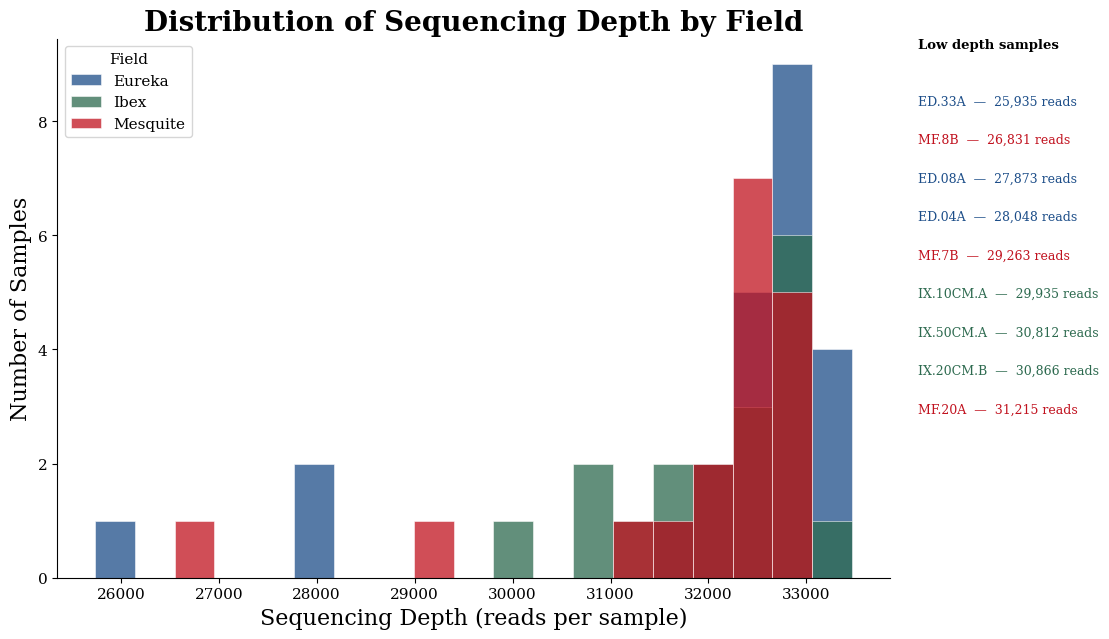

In [1]:
#SEQUENCING DEPTH FIGURE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================
# LOAD
# ============================
path = "/content/zotutab_decontam_Final_withdepth.csv"

raw = pd.read_csv(path, header=None)
df  = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

# ============================
# IDENTIFY SAMPLE COLUMNS
# ============================
tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

print(f"Loaded: {df.shape}")
print(f"Sample columns: {len(sample_cols)}")
print(f"First 3 samples: {sample_cols[:3]}")

# ============================
# COMPUTE METRICS
# ============================
seq_depth = df[sample_cols].sum(axis=0)

def compute_alpha(counts):
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0, 0
    p = counts / counts.sum()
    return -np.sum(p * np.log(p)), len(counts)

shannon_vals  = np.array([compute_alpha(df[s].values)[0]
                          for s in sample_cols])
richness_vals = np.array([compute_alpha(df[s].values)[1]
                          for s in sample_cols])

rho_sh,   p_sh   = spearmanr(seq_depth, shannon_vals)
rho_rich, p_rich = spearmanr(seq_depth, richness_vals)

print(f"\nDepth vs Shannon : rho={rho_sh:.3f}  p={p_sh:.2e}")
print(f"Depth vs Richness: rho={rho_rich:.3f}  p={p_rich:.2e}")

print(f"\nSequencing depth summary:")
print(f"  Mean:    {seq_depth.mean():.0f}")
print(f"  Median:  {seq_depth.median():.0f}")
print(f"  Min:     {seq_depth.min():.0f}")
print(f"  Max:     {seq_depth.max():.0f}")
print(f"  SD:      {seq_depth.std():.0f}")

# ============================
# FIELD ASSIGNMENT
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

FIELD_COLORS = {
    "Eureka":   "#1d4e89",
    "Ibex":     "#2d6a4f",
    "Mesquite": "#c1121f"
}

fields    = [get_field(s) for s in sample_cols]
depth_arr = seq_depth.values
threshold = np.percentile(depth_arr, 15)

low_depth = sorted(
    [(s, d, f) for s, d, f in zip(sample_cols, depth_arr, fields)
     if d <= threshold],
    key=lambda x: x[1]
)

print(f"\n15th percentile threshold: {threshold:.0f} reads")
print(f"Samples below threshold:   {len(low_depth)}")

# ============================
# FIGURE
# ============================
plt.rcParams.update({"font.family": "serif", "font.size": 10})
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("white")
fig.subplots_adjust(right=0.72)

bins = np.linspace(depth_arr.min() - 200,
                   depth_arr.max() + 200, 20)

for field, color in FIELD_COLORS.items():
    field_depths = [d for d, f in zip(depth_arr, fields)
                    if f == field]
    ax.hist(field_depths, bins=bins, color=color, alpha=0.75,
            edgecolor="white", linewidth=0.5, label=field)

# low depth sample list outside plot
y_start = 0.88
fig.text(0.74, y_start,
         "Low depth samples\n",
         fontsize=9.5, fontweight="bold",
         va="top", ha="left",
         transform=fig.transFigure)

for i, (s, d, f) in enumerate(low_depth):
    fig.text(
        0.74, y_start - 0.08 - i * 0.055,
        f"{s}  —  {d:,} reads",
        fontsize=9,
        color=FIELD_COLORS.get(f, "gray"),
        va="top", ha="left",
        transform=fig.transFigure
    )

ax.set_xlabel("Sequencing Depth (reads per sample)", fontsize=16)
ax.set_ylabel("Number of Samples", fontsize=16)
ax.set_title("Distribution of Sequencing Depth by Field",
             fontsize=20, fontweight="bold")
ax.legend(title="Field", fontsize=11, title_fontsize=11,
          frameon=True, edgecolor="#cccccc")
ax.tick_params(labelsize=11)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
plt.show()

In [2]:
import pandas as pd
import numpy as np

# ============================
# LOAD SURFACE COUNT FILE
# ============================
path = "/content/zotutab_decontam_Final.csv"
raw  = pd.read_csv(path, header=None)

first_val = str(raw.iloc[0, 0]).strip().upper()
if first_val == "ANATOMY":
    header_row = 1
    data_start = 2
else:
    header_row = 0
    data_start = 1

df = raw.iloc[data_start:].copy()
df.columns = raw.iloc[header_row].values
df.reset_index(drop=True, inplace=True)

tax_cols  = ["Domain", "Phylum", "Class", "Order",
             "Family", "Genus", "Species"]
zotu_col  = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

# ============================
# RICHNESS PER SAMPLE
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

richness = {}
for s in sample_cols:
    counts     = micro[s].values.astype(float)
    richness[s] = int((counts > 0).sum())

rich_df = pd.DataFrame([
    {"Sample": s,
     "Field":   get_field(s),
     "Richness": r}
    for s, r in richness.items()
    if get_field(s) != "Other"
])

# ============================
# SUMMARY BY FIELD
# ============================
print("=" * 55)
print("RICHNESS SUMMARY BY FIELD")
print("=" * 55)

summary = rich_df.groupby("Field")["Richness"].agg(
    Min="min", Max="max", Mean="mean",
    Median="median", SD="std", N="count"
).round(1)

print(summary.to_string())

print(f"\nOverall:")
print(f"  Min:    {rich_df['Richness'].min()}")
print(f"  Max:    {rich_df['Richness'].max()}")
print(f"  Mean:   {rich_df['Richness'].mean():.1f}")
print(f"  Median: {rich_df['Richness'].median():.1f}")

# ============================
# WHICH SAMPLE HAS MIN/MAX
# ============================
print(f"\nSample with lowest richness:")
min_row = rich_df.loc[rich_df["Richness"].idxmin()]
print(f"  {min_row['Sample']} ({min_row['Field']}): "
      f"{min_row['Richness']} ZOTUs")

print(f"\nSample with highest richness:")
max_row = rich_df.loc[rich_df["Richness"].idxmax()]
print(f"  {max_row['Sample']} ({max_row['Field']}): "
      f"{max_row['Richness']} ZOTUs")

# ============================
# FULL SAMPLE LIST PER FIELD
# ============================
print(f"\n{'='*55}")
print("ALL SAMPLES BY FIELD")
print(f"{'='*55}")
for field in ["Eureka", "Mesquite", "Ibex"]:
    subset = rich_df[rich_df["Field"] == field].sort_values(
        "Richness")
    print(f"\n{field}:")
    print(subset[["Sample", "Richness"]].to_string(index=False))
    print(rich_df.groupby("Field")["Richness"].mean().round(0))
print(f"\nOverall mean: {rich_df['Richness'].mean():.0f}")

RICHNESS SUMMARY BY FIELD
           Min   Max    Mean  Median     SD   N
Field                                          
Eureka     939  2562  1515.1  1505.5  293.4  24
Ibex      1417  2306  1603.4  1494.5  264.0  10
Mesquite  1196  2554  1739.1  1615.5  393.2  18

Overall:
  Min:    939
  Max:    2562
  Mean:   1609.6
  Median: 1536.5

Sample with lowest richness:
  ED.04A (Eureka): 939 ZOTUs

Sample with highest richness:
  ED.33A (Eureka): 2562 ZOTUs

ALL SAMPLES BY FIELD

Eureka:
Sample  Richness
ED.04A       939
ED.05A      1185
ED.08A      1203
ED.02B      1230
ED.03A      1351
ED.22A      1359
ED.12A      1391
ED.17B      1435
ED.09A      1444
ED.06A      1446
ED.24A      1487
ED.14B      1497
ED.13A      1514
ED.16A      1517
ED.23A      1528
ED.18A      1566
ED.15B      1650
ED.21A      1653
ED.20A      1657
ED.10A      1663
ED.19A      1673
ED.11A      1706
ED.01A      1707
ED.33A      2562
Field
Eureka      1515.0
Ibex        1603.0
Mesquite    1739.0
Name: Richness, dtype:

In [4]:
import pandas as pd
import numpy as np

# ============================
# LOAD RELATIVE ABUNDANCE FILE
# already standardised — no rename map needed
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

df = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

sample_cols = [s for s in df.columns[1:-7]
               if "Blank" not in str(s)]
df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

# ============================
# STANDARDISE AND FILTER
# file already clean — filter by domain only
# ============================
df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Total prokaryotic ZOTUs: {len(micro)}")
print(f"Unique phyla:            {micro['Phylum'].nunique()}")

# ============================
# FIELD GROUPS
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

eureka_samples   = [s for s in sample_cols if get_field(s) == "Eureka"]
mesquite_samples = [s for s in sample_cols if get_field(s) == "Mesquite"]
ibex_samples     = [s for s in sample_cols if get_field(s) == "Ibex"]

print(f"\nEureka:   {len(eureka_samples)} samples")
print(f"Mesquite: {len(mesquite_samples)} samples")
print(f"Ibex:     {len(ibex_samples)} samples")

# ============================
# AGGREGATE TO PHYLUM
# ============================
phylum_grouped = micro.groupby("Phylum")[sample_cols].sum()
print(f"\nTotal phyla after aggregation: {len(phylum_grouped)}")

# ============================
# FIELD MEANS AND PREVALENCE
# ============================
def get_prev(df, samps):
    return (df[samps] > 0).sum(axis=1) / len(samps)

e_prev = get_prev(phylum_grouped, eureka_samples)
m_prev = get_prev(phylum_grouped, mesquite_samples)
i_prev = get_prev(phylum_grouped, ibex_samples)

eureka_mean   = phylum_grouped[eureka_samples].mean(axis=1)
mesquite_mean = phylum_grouped[mesquite_samples].mean(axis=1)
ibex_mean     = phylum_grouped[ibex_samples].mean(axis=1)
max_field_mean = pd.concat(
    [eureka_mean, mesquite_mean, ibex_mean], axis=1).max(axis=1)

# ============================
# CLASSIFY EACH PHYLUM
# ============================
core_all = (e_prev >= 0.80) & (m_prev >= 0.80) & (i_prev >= 0.80)

core_e   = e_prev >= 0.80
core_m   = m_prev >= 0.80
core_i   = i_prev >= 0.80
partial  = (core_e | core_m | core_i) & ~core_all

dominant = max_field_mean >= 1.0

# ============================
# COUNTS
# ============================
n_total         = len(phylum_grouped)
n_core_all      = core_all.sum()
n_core_dom      = (core_all & dominant).sum()
n_core_rare     = (core_all & ~dominant).sum()
n_partial       = partial.sum()
n_non_core      = (~core_all & ~partial).sum()
n_non_core_dom  = (~core_all & ~partial & dominant).sum()
n_non_core_rare = (~core_all & ~partial & ~dominant).sum()

print("\n" + "="*60)
print("PHYLUM CLASSIFICATION SUMMARY")
print("="*60)
print(f"Total prokaryotic phyla:              {n_total}")
print(f"  Core (≥80% all 3 fields):          {n_core_all}")
print(f"    Core + dominant (>1% mean):       {n_core_dom}")
print(f"    Core + rare (≤1% mean):           {n_core_rare}")
print(f"  Partial core (≥80% in 1-2 fields): {n_partial}")
print(f"  Non-core (<80% in all fields):      {n_non_core}")
print(f"    Non-core + dominant:              {n_non_core_dom}")
print(f"    Non-core + rare:                  {n_non_core_rare}")
print(f"\nCheck: {n_core_all} + {n_partial} + {n_non_core} = "
      f"{n_core_all + n_partial + n_non_core} (should = {n_total})")

# ============================
# PRINT EACH CATEGORY
# ============================
print("\n" + "="*60)
print("CORE + DOMINANT (≥80% all fields AND >1% mean)")
print("="*60)
for p in phylum_grouped[core_all & dominant].index:
    print(f"  {p:<40} "
          f"E:{eureka_mean[p]:.2f}%  "
          f"M:{mesquite_mean[p]:.2f}%  "
          f"I:{ibex_mean[p]:.2f}%")

print("\n" + "="*60)
print("CORE + RARE (≥80% all fields BUT ≤1% mean)")
print("="*60)
for p in phylum_grouped[core_all & ~dominant].index:
    print(f"  {p:<40} "
          f"E:{eureka_mean[p]:.4f}%  "
          f"M:{mesquite_mean[p]:.4f}%  "
          f"I:{ibex_mean[p]:.4f}%")

print("\n" + "="*60)
print("PARTIAL CORE (≥80% in 1 or 2 fields only)")
print("="*60)
for p in phylum_grouped[partial].index:
    fields_core = []
    if core_e[p]: fields_core.append("Eureka")
    if core_m[p]: fields_core.append("Mesquite")
    if core_i[p]: fields_core.append("Ibex")
    print(f"  {p:<40} "
          f"core in: {', '.join(fields_core)}")
    print(f"  {'':40} "
          f"E prev:{e_prev[p]:.0%}  "
          f"M prev:{m_prev[p]:.0%}  "
          f"I prev:{i_prev[p]:.0%}")

print("\n" + "="*60)
print("NON-CORE (<80% prevalence in all fields)")
print("="*60)
for p in phylum_grouped[~core_all & ~partial].index:
    dom_label = "dominant" if dominant[p] else "rare"
    print(f"  {p:<40} {dom_label:<10} "
          f"max mean: {max_field_mean[p]:.4f}%  "
          f"E prev:{e_prev[p]:.0%}  "
          f"M prev:{m_prev[p]:.0%}  "
          f"I prev:{i_prev[p]:.0%}")

# ============================
# ADDITIONAL CHECK
# of non-dominant phyla — do any exceed 1%
# in at least one individual sample even though
# their field-level mean is below 1%?
# ============================
print("\n" + "="*60)
print("SAMPLE-LEVEL SPIKE CHECK")
print("Non-dominant phyla that exceed 1% in ≥1 individual sample")
print("="*60)

max_sample_val = phylum_grouped.max(axis=1)

rare_phyla      = max_field_mean[max_field_mean < 1.0].index
rare_but_spikes = [p for p in rare_phyla
                   if max_sample_val[p] >= 1.0]
rare_never      = [p for p in rare_phyla
                   if max_sample_val[p] < 1.0]

print(f"\nNon-dominant phyla (field mean <1%):        {len(rare_phyla)}")
print(f"  Spike >1% in ≥1 individual sample:        {len(rare_but_spikes)}")
print(f"  Never exceed 1% in any sample:            {len(rare_never)}")

if rare_but_spikes:
    print(f"\nPhyla that spike in individual samples:")
    for p in sorted(rare_but_spikes):
        print(f"  {p:<40} "
              f"max sample: {max_sample_val[p]:.2f}%  "
              f"max field mean: {max_field_mean[p]:.4f}%")

print(f"\nPhyla never exceeding 1% in any sample:")
for p in sorted(rare_never):
    print(f"  {p:<40} "
          f"max sample: {max_sample_val[p]:.4f}%")

# ============================
# SUMMARY FOR MANUSCRIPT TEXT
# ============================
print("\n" + "="*60)
print("MANUSCRIPT NUMBERS SUMMARY")
print("="*60)
print(f"Total phyla:                          {n_total}")
print(f"Dominant (>1% mean in ≥1 field):      {dominant.sum()}")
print(f"Non-dominant (<1% mean all fields):   {(~dominant).sum()}")
print(f"  Of these — spike >1% in a sample:  {len(rare_but_spikes)}")
print(f"  Of these — never exceed 1%:        {len(rare_never)}")
print(f"\nCore all 3 fields:                    {n_core_all}")
print(f"  Core + dominant:                    {n_core_dom}")
print(f"  Core + rare:                        {n_core_rare}")
print(f"Partial core (1-2 fields):            {n_partial}")
print(f"Non-core:                             {n_non_core}")

# ============================
# SAVE
# ============================
summary = pd.DataFrame({
    "Eureka_prev":    e_prev.round(3),
    "Mesquite_prev":  m_prev.round(3),
    "Ibex_prev":      i_prev.round(3),
    "Eureka_mean":    eureka_mean.round(4),
    "Mesquite_mean":  mesquite_mean.round(4),
    "Ibex_mean":      ibex_mean.round(4),
    "Max_field_mean": max_field_mean.round(4),
    "Max_sample_val": max_sample_val.round(4),
    "Core_all":       core_all,
    "Partial_core":   partial,
    "Dominant":       dominant,
}).sort_values("Max_field_mean", ascending=False)



Total prokaryotic ZOTUs: 6014
Unique phyla:            36

Eureka:   24 samples
Mesquite: 18 samples
Ibex:     10 samples

Total phyla after aggregation: 36

PHYLUM CLASSIFICATION SUMMARY
Total prokaryotic phyla:              36
  Core (≥80% all 3 fields):          19
    Core + dominant (>1% mean):       11
    Core + rare (≤1% mean):           8
  Partial core (≥80% in 1-2 fields): 4
  Non-core (<80% in all fields):      13
    Non-core + dominant:              0
    Non-core + rare:                  13

Check: 19 + 4 + 13 = 36 (should = 36)

CORE + DOMINANT (≥80% all fields AND >1% mean)
  acidobacteriota                          E:2.11%  M:1.57%  I:1.87%
  actinomycetota                           E:25.28%  M:27.25%  I:21.18%
  bacillota                                E:6.08%  M:8.49%  I:7.02%
  bacteroidota                             E:19.65%  M:15.68%  I:18.22%
  chloroflexota                            E:4.14%  M:5.03%  I:3.57%
  gemmatimonadota                          E:1.36% 

Total samples: 52
First 3: ['MF.4B', 'MF.5B', 'MF.6B']
Prokaryotic ZOTUs: 6014

Eureka:   24 samples
Mesquite: 18 samples
Ibex:     10 samples

CORE PHYLA (surface samples only — depth excluded)

PHYLUM                                EUREKA  MESQUITE    IBEX   OVERALL   DOM
-----------------------------------------------------------------
pseudomonadota                        32.11%    28.99%  35.86%    32.32%   YES
actinomycetota                        25.28%    27.25%  21.18%    24.57%   YES
bacteroidota                          19.65%    15.68%  18.22%    17.85%   YES
bacillota                              6.08%     8.49%   7.02%     7.20%   YES
chloroflexota                          4.14%     5.03%   3.57%     4.25%   YES
methanobacteriota                      2.55%     2.44%   3.37%     2.79%   YES
planctomycetota                        2.24%     2.78%   1.92%     2.31%   YES
gemmatimonadota                        1.36%     2.18%   2.13%     1.89%   YES
acidobacteriota            

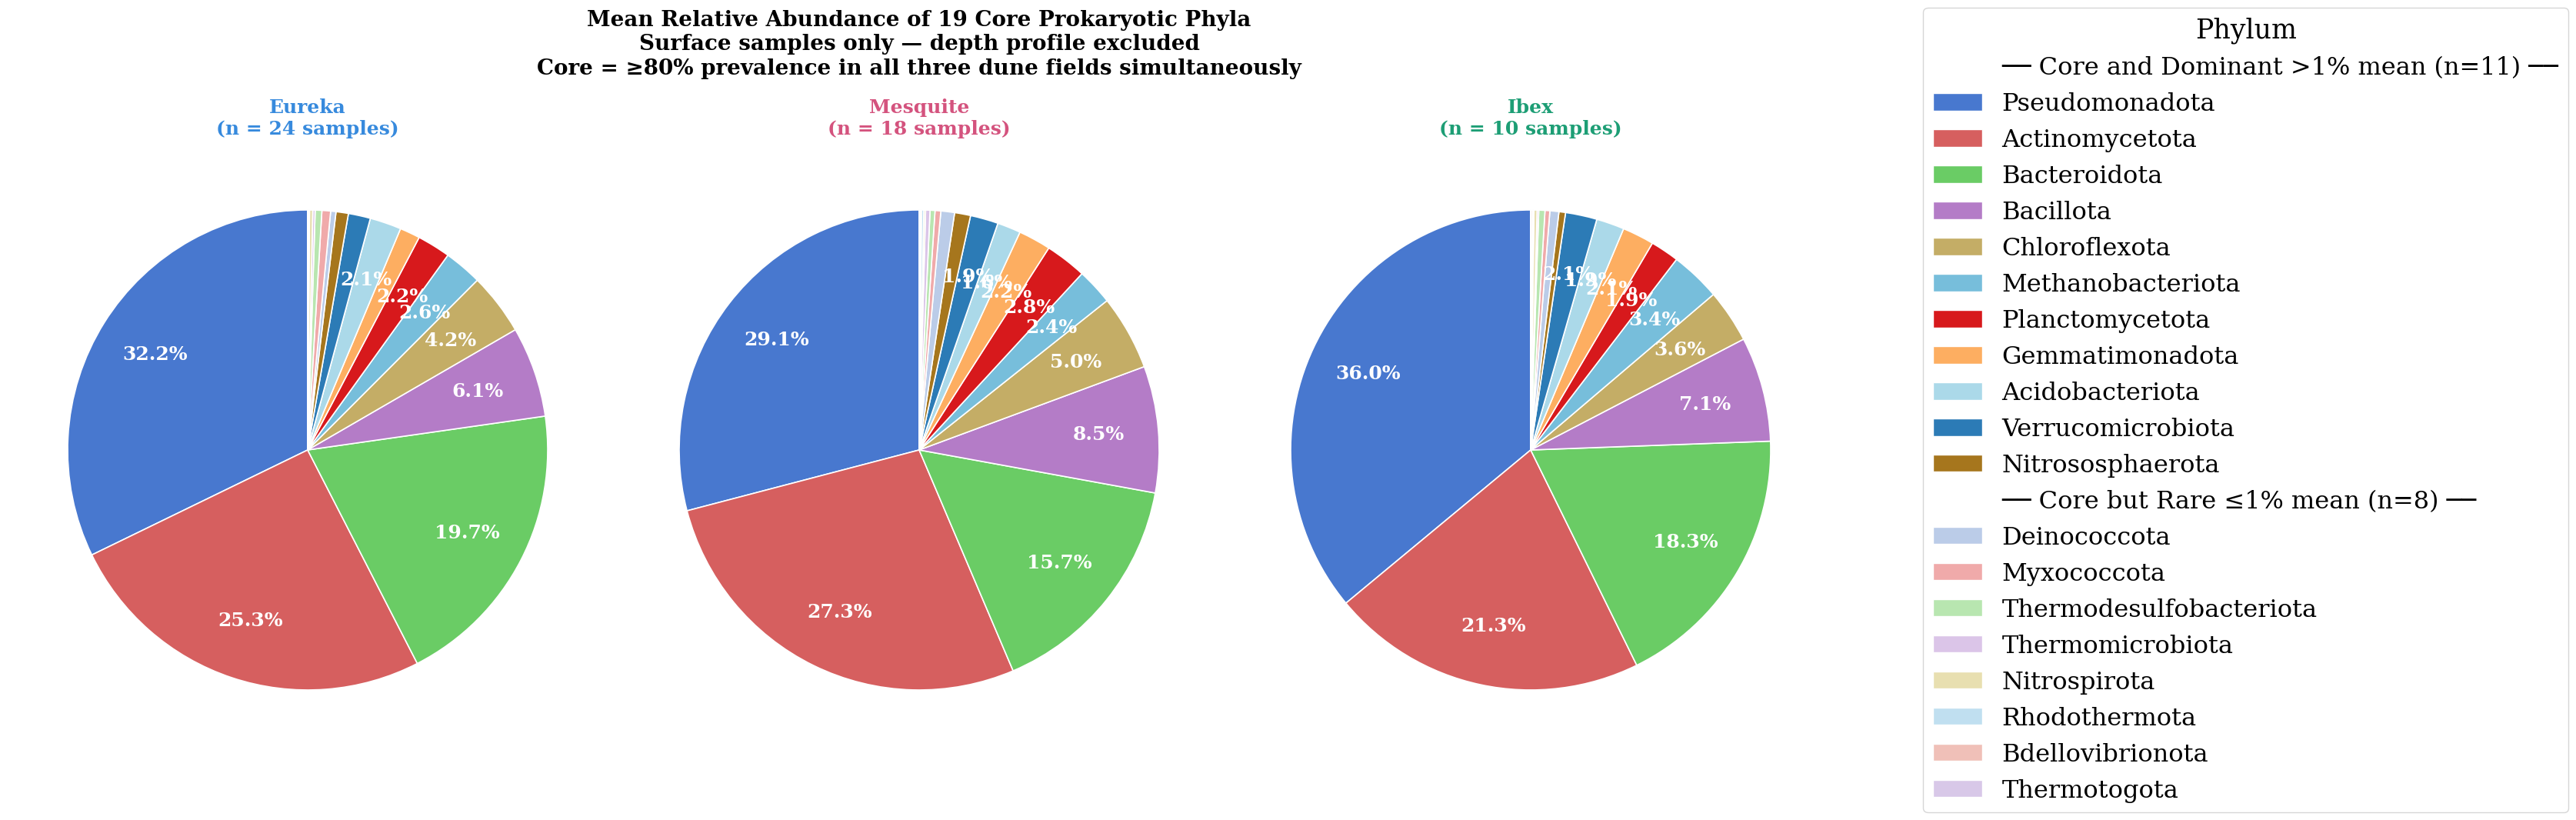

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================
# LOAD FILE
# no depth samples in this file
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

# ============================
# IDENTIFY SAMPLE COLUMNS
# exclude blanks
# ============================
tax_cols    = ["Domain", "Phylum", "Class", "Order",
               "Family", "Genus", "Species"]
zotu_col    = df.columns[0]
sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

print(f"Total samples: {len(sample_cols)}")
print(f"First 3: {sample_cols[:3]}")

# ============================
# FILTER BACTERIA + ARCHAEA
# file already standardised — no rename map needed
# ============================
micro_df = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro_df)}")

# ============================
# FIELD MAP
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

field_groups = {
    "Eureka":   [s for s in sample_cols if get_field(s) == "Eureka"],
    "Mesquite": [s for s in sample_cols if get_field(s) == "Mesquite"],
    "Ibex":     [s for s in sample_cols if get_field(s) == "Ibex"],
}

print(f"\nEureka:   {len(field_groups['Eureka'])} samples")
print(f"Mesquite: {len(field_groups['Mesquite'])} samples")
print(f"Ibex:     {len(field_groups['Ibex'])} samples")

# ============================
# AGGREGATE TO PHYLUM
# ============================
phylum_rel = micro_df.groupby("Phylum")[sample_cols].sum()
presence   = (phylum_rel > 0).astype(int)

# ============================
# PREVALENCE + MEAN PER FIELD
# ============================
results = []
for phylum in phylum_rel.index:
    row = {"Phylum": phylum}
    for field, fsamps in field_groups.items():
        row[f"{field}_prev"] = presence.loc[phylum, fsamps].mean()
        row[f"{field}_mean"] = phylum_rel.loc[phylum, fsamps].mean()
    results.append(row)

phylum_df = pd.DataFrame(results)

# ============================
# CORE PHYLA
# ≥80% prevalence in ALL THREE fields
# ============================
core_mask = (
    (phylum_df["Eureka_prev"]   >= 0.80) &
    (phylum_df["Mesquite_prev"] >= 0.80) &
    (phylum_df["Ibex_prev"]     >= 0.80)
)
core_df = phylum_df[core_mask].copy()
core_df["Max_field_mean"] = core_df[[
    "Eureka_mean", "Mesquite_mean", "Ibex_mean"]].max(axis=1)
core_df["Dominant"]     = core_df["Max_field_mean"] >= 1.0
core_df["Overall_mean"] = core_df[[
    "Eureka_mean", "Mesquite_mean", "Ibex_mean"]].mean(axis=1)
core_df = core_df.sort_values(
    "Overall_mean", ascending=False).reset_index(drop=True)

# ============================
# PARTIAL CORE
# ≥80% in 1 or 2 fields only
# ============================
partial_mask = (
    ~core_mask &
    (
        (phylum_df["Eureka_prev"]   >= 0.80) |
        (phylum_df["Mesquite_prev"] >= 0.80) |
        (phylum_df["Ibex_prev"]     >= 0.80)
    )
)
partial_df = phylum_df[partial_mask].copy()

def partial_label(row):
    fields = [f for f in ["Eureka", "Mesquite", "Ibex"]
              if row[f"{f}_prev"] >= 0.80]
    return " + ".join(fields)

partial_df["Fields_core"] = partial_df.apply(partial_label, axis=1)

# ============================
# SUMMARY
# ============================
n_core     = len(core_df)
n_dominant = core_df["Dominant"].sum()
n_rare     = (~core_df["Dominant"]).sum()

print(f"\n{'='*65}")
print(f"CORE PHYLA (surface samples only — depth excluded)")
print(f"{'='*65}")
print(f"\n{'PHYLUM':<35} {'EUREKA':>8} {'MESQUITE':>9} "
      f"{'IBEX':>7} {'OVERALL':>9} {'DOM':>5}")
print("-"*65)
for _, row in core_df.iterrows():
    dom = "YES" if row["Dominant"] else "no"
    print(f"{row['Phylum']:<35} "
          f"{row['Eureka_mean']:>7.2f}% "
          f"{row['Mesquite_mean']:>8.2f}% "
          f"{row['Ibex_mean']:>6.2f}% "
          f"{row['Overall_mean']:>8.2f}% "
          f"{dom:>5}")

print(f"\nTotal core phyla (all 3 fields):      {n_core}")
print(f"Core and dominant (>1% in ≥1 field):  {n_dominant}")
print(f"Core but rare (<1% in all fields):    {n_rare}")
print(f"\nPartial core (1-2 fields only):       {len(partial_df)}")
for _, row in partial_df.iterrows():
    print(f"  {row['Phylum']:<35} {row['Fields_core']}")

for field in ["Eureka", "Mesquite", "Ibex"]:
    n = (phylum_df[f"{field}_prev"] >= 0.80).sum()
    print(f"{field} total core phyla: {n}")

# ============================
# COLOR PALETTE
# consistent color per phylum across all 3 pies
# dominant = vivid, rare = muted
# ============================
dominant_colors = [
    "#4878CF", "#D65F5F", "#6ACC65", "#B47CC7",
    "#C4AD66", "#77BEDB", "#D7191C", "#FDAE61",
    "#ABD9E9", "#2C7BB6", "#A6761D", "#E6AB02",
    "#1B9E77", "#984EA3",
]
rare_colors = [
    "#BBCCE8", "#F0AAAA", "#B8E6B0", "#DBC5E8",
    "#E8DFB0", "#C0DFF0", "#F0C0B8", "#D8C8E8",
]

phylum_color_map = {}
dom_idx  = 0
rare_idx = 0
for _, row in core_df.iterrows():
    if row["Dominant"]:
        phylum_color_map[row["Phylum"]] = dominant_colors[dom_idx]
        dom_idx += 1
    else:
        phylum_color_map[row["Phylum"]] = rare_colors[rare_idx]
        rare_idx += 1

# ============================
# FIGURE — 3 pie charts
# ============================
field_names        = ["Eureka", "Mesquite", "Ibex"]
field_cols         = ["Eureka_mean", "Mesquite_mean", "Ibex_mean"]
field_title_colors = ["#378ADD", "#D4537E", "#1D9E75"]
n_samples          = {f: len(s) for f, s in field_groups.items()}

fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.patch.set_facecolor("white")

for ax, field, col, title_color in zip(
        axes, field_names, field_cols, field_title_colors):

    vals   = core_df[col].values
    colors = [phylum_color_map[p] for p in core_df["Phylum"]]

    def autopct_fmt(pct):
        return f"{pct:.1f}%" if pct >= 1.5 else ""

    wedges, texts, autotexts = ax.pie(
        vals,
        colors=colors,
        autopct=autopct_fmt,
        pctdistance=0.75,
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.2),
    )

    for autotext in autotexts:
        autotext.set_fontsize(18)
        autotext.set_fontweight("bold")
        autotext.set_color("white")

    ax.set_title(
        f"{field}\n(n = {n_samples[field]} samples)",
        fontsize=18, fontweight="bold",
        color=title_color, pad=15)

# ============================
# SINGLE LEGEND — phyla listed once
# ============================
legend_handles = []

legend_handles.append(
    Patch(facecolor="none", edgecolor="none",
          label=f"── Core and Dominant >1% mean (n={n_dominant}) ──"))
for _, row in core_df[core_df["Dominant"]].iterrows():
    legend_handles.append(
        Patch(facecolor=phylum_color_map[row["Phylum"]],
              edgecolor="white",
              label=row["Phylum"].capitalize()))

legend_handles.append(
    Patch(facecolor="none", edgecolor="none",
          label=f"── Core but Rare ≤1% mean (n={n_rare}) ──"))
for _, row in core_df[~core_df["Dominant"]].iterrows():
    legend_handles.append(
        Patch(facecolor=phylum_color_map[row["Phylum"]],
              edgecolor="white",
              label=row["Phylum"].capitalize()))

fig.legend(
    handles=legend_handles,
    loc="center right",
    bbox_to_anchor=(1.4, 0.5),
    fontsize=23,
    frameon=True,
    edgecolor="#cccccc",
    title="Phylum",
    title_fontsize=25,
)

fig.suptitle(
    f"Mean Relative Abundance of {n_core} Core Prokaryotic Phyla\n"
    f"Surface samples only — depth profile excluded\n"
    f"Core = ≥80% prevalence in all three dune fields simultaneously",
    fontsize=20, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

In [6]:
# See all 36 phyla detected and their domain
print("All phyla detected:")
print(phylum_df[["Phylum", "Eureka_mean", "Mesquite_mean", "Ibex_mean"]].to_string())


All phyla detected:
                         Phylum  Eureka_mean  Mesquite_mean  Ibex_mean
0              abditibacteriota     0.035771       0.019694   0.025171
1               acidobacteriota     2.109786       1.573517   1.874071
2                actinomycetota    25.275579      27.246979  21.177390
3                armatimonadota     0.008889       0.009185   0.023327
4                 atribacterota     0.006437       0.001420   0.003146
5                     bacillota     6.081466       8.490120   7.022013
6                  bacteroidota    19.648656      15.681307  18.215555
7                    balneolota     0.001037       0.022910   0.000000
8              bdellovibrionota     0.049487       0.089386   0.101210
9              campylobacterota     0.000381       0.000000   0.204146
10   candidatus melainabacteria     0.000130       0.006812   0.000306
11  candidatus saccharibacteria     0.006743       0.010156   0.000000
12     candidatus tectomicrobia     0.036172       0.0137

CORE PHYLA PER DUNE FIELD

  file: zotutab_decontam_Final.csv
  6014 zOTUs x 52 samples
    Eureka      24 samples   (core needs presence in >= 20)
    Mesquite    18 samples   (core needs presence in >= 15)
    Ibex        10 samples   (core needs presence in >= 8)

  collapsed to 36 phyla
    Eureka     core phyla:  21  of 36
    Mesquite   core phyla:  21  of 36
    Ibex       core phyla:  22  of 36

CORE PHYLUM CATEGORIES

  all three fields  (n=19)
      Acidobacteriota
      Actinomycetota
      Bacillota
      Bacteroidota
      Bdellovibrionota
      Chloroflexota
      Deinococcota
      Gemmatimonadota
      Methanobacteriota
      Myxococcota
      Nitrososphaerota
      Nitrospirota
      Planctomycetota
      Pseudomonadota
      Rhodothermota
      Thermodesulfobacteriota
      Thermomicrobiota
      Thermotogota
      Verrucomicrobiota

  Eureka + Mesquite only  (n=1)
      Abditibacteriota

  Eureka + Ibex only  (n=1)
      Ca. Tectomicrobia

  Mesquite + Ibex only  (n=

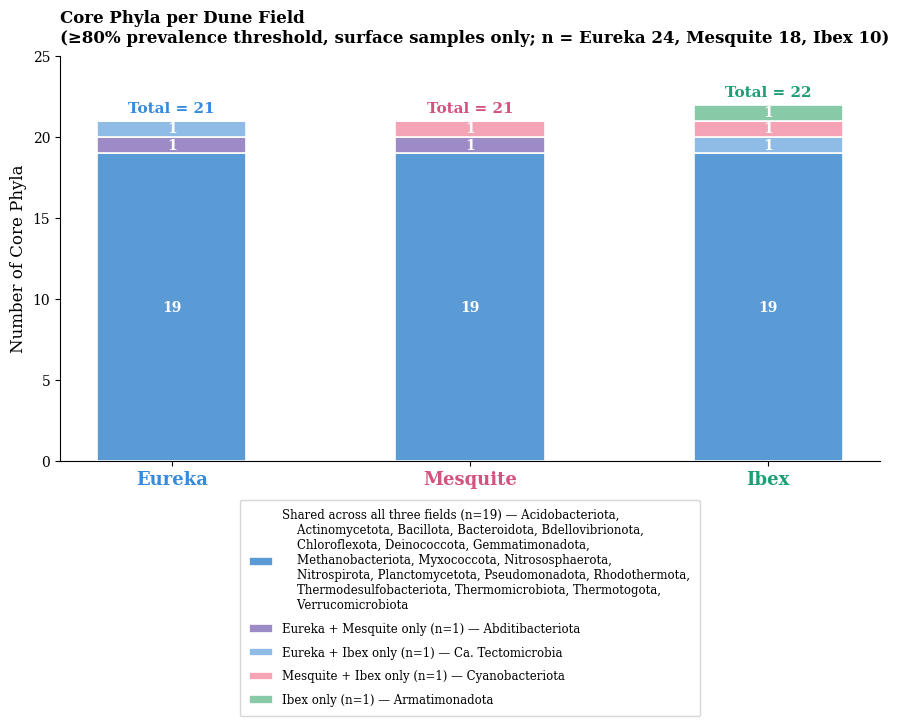


  Eureka: 21   Mesquite: 21   Ibex: 22
  shared by all three: 19


In [10]:
# =====================================================================
# CORE PHYLA PER DUNE FIELD
#
# Reads zotutab_decontam_Final.csv (surface samples only) and works out
# which phyla are "core" to each field, rather than having the numbers
# and names typed in by hand.
#
# core = present in at least PREVALENCE_THRESHOLD of that field's samples
# present = the phylum has more than MIN_READS reads in that sample
#           (reads summed across all zOTUs belonging to the phylum)
#
# Every category in the stacked bar is derived from the data, including
# the phylum names printed in the legend.
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import textwrap, csv

# ---------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------
IN_FILE  = "/content/zotutab_decontam_Final.csv"
OUT_CSV  = "/content/core_phyla_summary.csv"
OUT_PNG  = "/content/core_phyla_per_field.png"

PREVALENCE_THRESHOLD = 0.80   # 0.80 = present in >=80% of a field's samples
MIN_READS            = 0      # >MIN_READS counts as present; 0 = any read

# sample-name prefix -> field name
FIELD_PREFIX = {"ED": "Eureka", "MF": "Mesquite", "IX": "Ibex"}
FIELD_ORDER  = ["Eureka", "Mesquite", "Ibex"]

FIELD_COLORS = {"Eureka": "#378ADD", "Mesquite": "#D4537E", "Ibex": "#1D9E75"}

TAX_COLS = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

print("=" * 70)
print("CORE PHYLA PER DUNE FIELD")
print("=" * 70)


# ---------------------------------------------------------------------
# LOAD
# ---------------------------------------------------------------------
raw = pd.read_csv(IN_FILE, header=None, dtype=str)
if str(raw.iloc[0, 0]).strip().upper() != "ANATOMY":
    raise ValueError("Row 1 of the input is not the ANATOMY row.")

header = raw.iloc[1].tolist()
df     = raw.iloc[2:].copy()
df.columns = header
df.reset_index(drop=True, inplace=True)

sample_cols = [c for c in header[1:] if c not in TAX_COLS]


def field_of(col):
    for prefix, name in FIELD_PREFIX.items():
        if str(col).upper().startswith(prefix):
            return name
    return None


unassigned = [c for c in sample_cols if field_of(c) is None]
if unassigned:
    raise ValueError(f"These samples matched no field prefix: {unassigned}")

field_samples = {f: [c for c in sample_cols if field_of(c) == f]
                 for f in FIELD_ORDER}

print(f"\n  file: {IN_FILE.split('/')[-1]}")
print(f"  {len(df)} zOTUs x {len(sample_cols)} samples")
for f in FIELD_ORDER:
    n = len(field_samples[f])
    print(f"    {f:<10} {n:>3} samples   "
          f"(core needs presence in >= {int(np.ceil(PREVALENCE_THRESHOLD * n))})")


# ---------------------------------------------------------------------
# COLLAPSE zOTUs TO PHYLUM LEVEL
# ---------------------------------------------------------------------
counts = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
counts["Phylum"] = df["Phylum"].fillna("").str.strip().str.lower().values
phylum_table = counts.groupby("Phylum")[sample_cols].sum()

print(f"\n  collapsed to {len(phylum_table)} phyla")


# ---------------------------------------------------------------------
# PREVALENCE AND CORE MEMBERSHIP
# ---------------------------------------------------------------------
present = phylum_table > MIN_READS

prevalence, core_sets = {}, {}
for f in FIELD_ORDER:
    cols = field_samples[f]
    prevalence[f] = present[cols].sum(axis=1) / len(cols)
    core_sets[f] = set(prevalence[f][prevalence[f] >= PREVALENCE_THRESHOLD].index)
    print(f"    {f:<10} core phyla: {len(core_sets[f]):>3}  "
          f"of {len(phylum_table)}")


# ---------------------------------------------------------------------
# WHICH FIELDS IS EACH PHYLUM CORE TO?
# Every phylum is assigned to exactly one category: the exact set of
# fields it is core to.
# ---------------------------------------------------------------------
membership = {}
for ph in phylum_table.index:
    fields_in = frozenset(f for f in FIELD_ORDER if ph in core_sets[f])
    if fields_in:
        membership.setdefault(fields_in, []).append(ph)

# build the category list: all three first, then pairs, then singles
categories = []
all3 = frozenset(FIELD_ORDER)
if all3 in membership:
    categories.append(all3)
for combo in combinations(FIELD_ORDER, 2):
    fs = frozenset(combo)
    if fs in membership:
        categories.append(fs)
for f in FIELD_ORDER:
    fs = frozenset([f])
    if fs in membership:
        categories.append(fs)


def pretty(name):
    """Title-case a phylum label, keeping 'Candidatus' readable."""
    if name.startswith("candidatus "):
        return "Ca. " + name[11:].title()
    return name.title()


print("\n" + "=" * 70)
print("CORE PHYLUM CATEGORIES")
print("=" * 70)
for fs in categories:
    who = " + ".join(f for f in FIELD_ORDER if f in fs)
    names = sorted(membership[fs])
    tag = "all three fields" if len(fs) == 3 else f"{who} only"
    print(f"\n  {tag}  (n={len(names)})")
    for n in names:
        print(f"      {pretty(n)}")


# ---------------------------------------------------------------------
# PER-PHYLUM SUMMARY TABLE
# ---------------------------------------------------------------------
rows = []
for ph in phylum_table.index:
    fs = frozenset(f for f in FIELD_ORDER if ph in core_sets[f])
    rows.append({
        "Phylum": pretty(ph),
        **{f"prev_{f}": round(prevalence[f][ph], 3) for f in FIELD_ORDER},
        **{f"core_{f}": (f in fs) for f in FIELD_ORDER},
        "n_fields_core": len(fs),
        "category": ("all three" if len(fs) == 3
                     else " + ".join(f for f in FIELD_ORDER if f in fs) + " only"
                     if fs else "not core"),
        "total_reads": int(phylum_table.loc[ph].sum()),
    })
summary = (pd.DataFrame(rows)
           .sort_values(["n_fields_core", "total_reads"], ascending=[False, False])
           .reset_index(drop=True))
print(f"\n  wrote {OUT_CSV.split('/')[-1]}")

not_core = summary[summary["n_fields_core"] == 0]
print(f"  phyla core to no field: {len(not_core)}")
if len(not_core):
    print(f"    {', '.join(not_core['Phylum'].tolist())}")


# ---------------------------------------------------------------------
# PLOT
# ---------------------------------------------------------------------
# colour per category: shared = neutral blue, pairs and singles tinted
CATEGORY_COLORS = {
    frozenset(["Eureka", "Mesquite", "Ibex"]): "#5B9BD5",
    frozenset(["Eureka", "Ibex"]):             "#8FBCE6",
    frozenset(["Eureka", "Mesquite"]):         "#9C8BC7",
    frozenset(["Mesquite", "Ibex"]):           "#F4A4B5",
    frozenset(["Eureka"]):                     "#2E6FB0",
    frozenset(["Mesquite"]):                   "#B03C62",
    frozenset(["Ibex"]):                       "#88C9A8",
}

x = np.arange(len(FIELD_ORDER))
width = 0.5

fig, ax = plt.subplots(figsize=(9, 7.5))
fig.patch.set_facecolor("white")

bottom = np.zeros(len(FIELD_ORDER))
for fs in categories:
    names = sorted(membership[fs])
    # a category contributes to a field's bar only if it is core there
    heights = np.array([len(names) if f in fs else 0 for f in FIELD_ORDER],
                       dtype=float)

    who = " + ".join(f for f in FIELD_ORDER if f in fs)
    tag = "Shared across all three fields" if len(fs) == 3 else f"{who} only"
    label = f"{tag} (n={len(names)}) — " + ", ".join(pretty(n) for n in names)
    label = "\n    ".join(textwrap.wrap(label, 62))

    bars = ax.bar(x, heights, width, bottom=bottom, label=label,
                  color=CATEGORY_COLORS.get(fs, "#999999"),
                  edgecolor="white", linewidth=1.2)

    for bar, h, b in zip(bars, heights, bottom):
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, b + h / 2,
                    str(int(h)), ha="center", va="center",
                    fontsize=10, fontweight="bold", color="white")
    bottom += heights

totals = [len(core_sets[f]) for f in FIELD_ORDER]
for i, (total, f) in enumerate(zip(totals, FIELD_ORDER)):
    ax.text(i, total + 0.3, f"Total = {total}", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=FIELD_COLORS[f])

ax.set_xticks(x)
ax.set_xticklabels(FIELD_ORDER, fontsize=13, fontweight="bold")
for tick, f in zip(ax.get_xticklabels(), FIELD_ORDER):
    tick.set_color(FIELD_COLORS[f])

ax.set_ylabel("Number of Core Phyla", fontsize=12)
ax.set_ylim(0, max(totals) + 3)
ax.set_title(
    f"Core Phyla per Dune Field\n"
    f"(\u2265{PREVALENCE_THRESHOLD:.0%} prevalence threshold, surface samples only; "
    f"n = {', '.join(f'{f} {len(field_samples[f])}' for f in FIELD_ORDER)})",
    fontsize=12, fontweight="bold", loc="left", pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legend below the axes: the category labels list every phylum name, so
# they are far too wide to sit inside the plot without covering the bars
ax.legend(fontsize=8.5, frameon=True, edgecolor="#CCCCCC",
          loc="upper center", bbox_to_anchor=(0.5, -0.08),
          labelspacing=0.9, borderpad=0.8)

plt.tight_layout()

plt.show()

print("\n" + "=" * 70)
print("  " + "   ".join(f"{f}: {len(core_sets[f])}" for f in FIELD_ORDER))
print(f"  shared by all three: {len(membership.get(all3, []))}")
print("=" * 70)

Total samples: 52
Prokaryotic ZOTUs: 6014


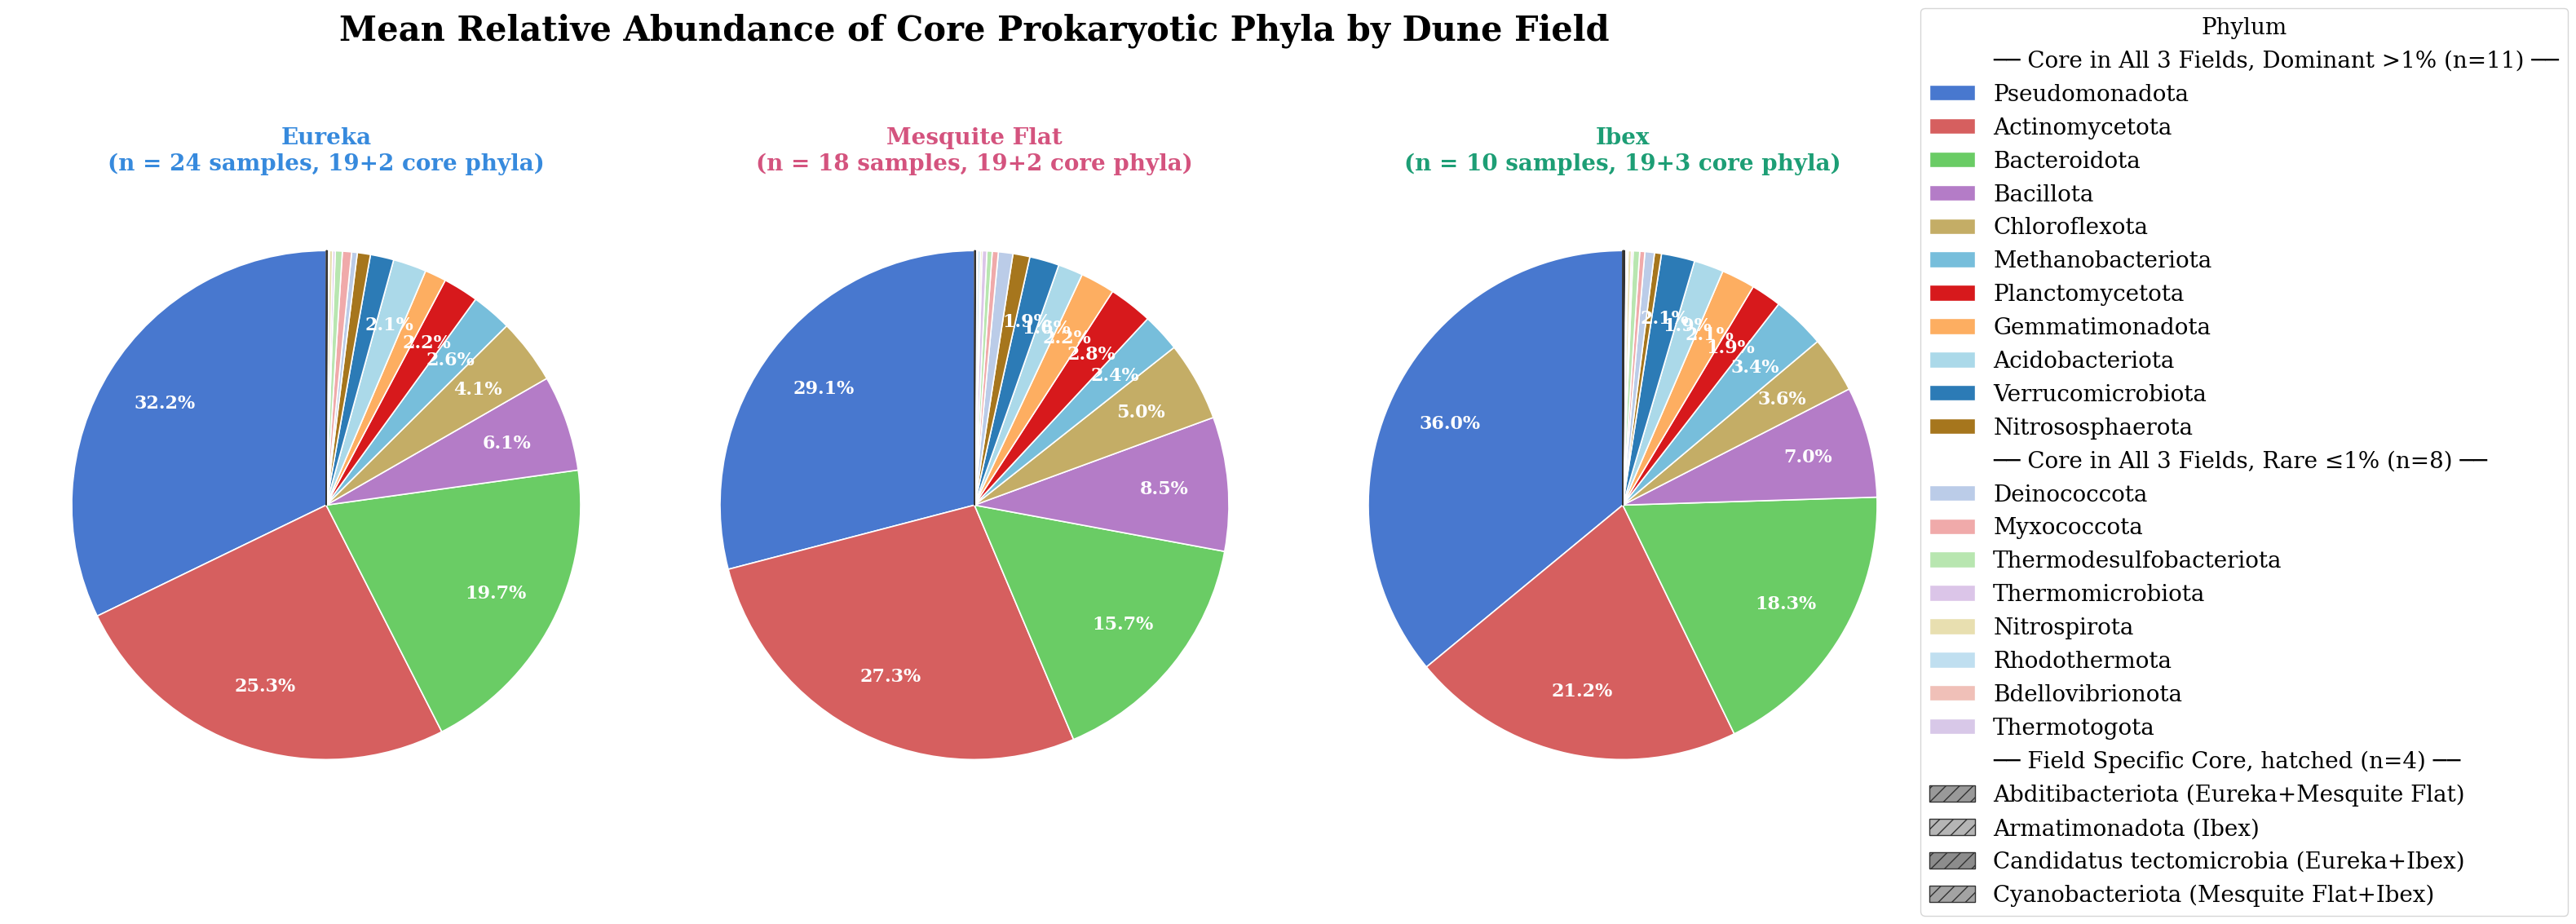

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================
# LOAD FILE
# no depth samples in this file
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

# ============================
# IDENTIFY SAMPLE COLUMNS
# exclude blanks
# ============================
tax_cols    = ["Domain", "Phylum", "Class", "Order",
               "Family", "Genus", "Species"]
zotu_col    = df.columns[0]
sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

print(f"Total samples: {len(sample_cols)}")

# ============================
# FILTER BACTERIA + ARCHAEA
# ============================
micro_df = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro_df)}")

# ============================
# FIELD MAP
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite Flat"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

field_groups = {
    "Eureka":   [s for s in sample_cols if get_field(s) == "Eureka"],
    "Mesquite Flat": [s for s in sample_cols if get_field(s) == "Mesquite Flat"],
    "Ibex":     [s for s in sample_cols if get_field(s) == "Ibex"],
}

# ============================
# AGGREGATE TO PHYLUM
# ============================
phylum_rel = micro_df.groupby("Phylum")[sample_cols].sum()
presence   = (phylum_rel > 0).astype(int)

results = []
for phylum in phylum_rel.index:
    row = {"Phylum": phylum}
    for field, fsamps in field_groups.items():
        row[f"{field}_prev"] = presence.loc[phylum, fsamps].mean()
        row[f"{field}_mean"] = phylum_rel.loc[phylum, fsamps].mean()
    results.append(row)

phylum_df = pd.DataFrame(results)

# ============================
# CORE (universal, all 3 fields) vs PARTIAL CORE (1-2 fields)
# ============================
core_mask = (
    (phylum_df["Eureka_prev"]   >= 0.80) &
    (phylum_df["Mesquite Flat_prev"] >= 0.80) &
    (phylum_df["Ibex_prev"]     >= 0.80)
)
core_df = phylum_df[core_mask].copy()
core_df["Max_field_mean"] = core_df[[
    "Eureka_mean", "Mesquite Flat_mean", "Ibex_mean"]].max(axis=1)
core_df["Dominant"]     = core_df["Max_field_mean"] >= 1.0
core_df["Overall_mean"] = core_df[[
    "Eureka_mean", "Mesquite Flat_mean", "Ibex_mean"]].mean(axis=1)
core_df = core_df.sort_values(
    "Overall_mean", ascending=False).reset_index(drop=True)

partial_mask = (
    ~core_mask &
    (
        (phylum_df["Eureka_prev"]   >= 0.80) |
        (phylum_df["Mesquite Flat_prev"] >= 0.80) |
        (phylum_df["Ibex_prev"]     >= 0.80)
    )
)
partial_df = phylum_df[partial_mask].copy()
partial_df["Max_field_mean"] = partial_df[[
    "Eureka_mean", "Mesquite Flat_mean", "Ibex_mean"]].max(axis=1)
partial_df["Dominant"] = partial_df["Max_field_mean"] >= 1.0

n_core     = len(core_df)
n_dominant = core_df["Dominant"].sum()
n_rare     = (~core_df["Dominant"]).sum()

# ============================
# COLOR PALETTE -- consistent per phylum across all 3 pies
# universal core phyla get assigned colors here;
# partial-core (field-specific) phyla get their own muted palette + hatch
# ============================
dominant_colors = [
    "#4878CF", "#D65F5F", "#6ACC65", "#B47CC7",
    "#C4AD66", "#77BEDB", "#D7191C", "#FDAE61",
    "#ABD9E9", "#2C7BB6", "#A6761D", "#E6AB02",
    "#1B9E77", "#984EA3",
]
rare_colors = [
    "#BBCCE8", "#F0AAAA", "#B8E6B0", "#DBC5E8",
    "#E8DFB0", "#C0DFF0", "#F0C0B8", "#D8C8E8",
]
partial_colors = [
    "#999999", "#B5B5B5", "#8C8C8C", "#A3A3A3",
    "#787878", "#BFBFBF", "#666666",
]

phylum_color_map = {}
dom_idx, rare_idx = 0, 0
for _, row in core_df.iterrows():
    if row["Dominant"]:
        phylum_color_map[row["Phylum"]] = dominant_colors[dom_idx]
        dom_idx += 1
    else:
        phylum_color_map[row["Phylum"]] = rare_colors[rare_idx]
        rare_idx += 1

partial_idx = 0
for phylum in partial_df["Phylum"]:
    phylum_color_map[phylum] = partial_colors[partial_idx % len(partial_colors)]
    partial_idx += 1

# ============================
# BUILD PER-FIELD WEDGE SETS
# universal core (no hatch) + this field's partial-core additions (hatched)
# ============================
field_names        = ["Eureka", "Mesquite Flat", "Ibex"]
field_cols         = ["Eureka_mean", "Mesquite Flat_mean", "Ibex_mean"]
field_prev_cols    = ["Eureka_prev", "Mesquite Flat_prev", "Ibex_prev"]
field_title_colors = ["#378ADD", "#D4537E", "#1D9E75"]
n_samples          = {f: len(s) for f, s in field_groups.items()}

field_wedges = {}
for field, mean_col, prev_col in zip(field_names, field_cols, field_prev_cols):
    # universal core wedges for this field
    labels  = list(core_df["Phylum"])
    vals    = list(core_df[mean_col])
    hatches = [None] * len(labels)

    # this field's field-specific (partial core) additions
    field_specific = partial_df[partial_df[prev_col] >= 0.80]
    for _, row in field_specific.iterrows():
        labels.append(row["Phylum"])
        vals.append(row[mean_col])
        hatches.append("//")

    field_wedges[field] = {"labels": labels, "vals": vals, "hatches": hatches}

# ============================
# FIGURE -- 3 pie charts, hatched wedges = field-specific core
# ============================
fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.patch.set_facecolor("white")

for ax, field, title_color in zip(axes, field_names, field_title_colors):
    labels  = field_wedges[field]["labels"]
    vals    = field_wedges[field]["vals"]
    hatches = field_wedges[field]["hatches"]
    colors  = [phylum_color_map[p] for p in labels]

    def autopct_fmt(pct):
        return f"{pct:.1f}%" if pct >= 1.5 else ""

    wedges, texts, autotexts = ax.pie(
        vals,
        colors=colors,
        autopct=autopct_fmt,
        pctdistance=0.75,
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.2),
    )

    for wedge, hatch in zip(wedges, hatches):
        if hatch:
            wedge.set_hatch(hatch)
            wedge.set_edgecolor("#333333")
            wedge.set_linewidth(1.0)

    for autotext in autotexts:
        autotext.set_fontsize(16)
        autotext.set_fontweight("bold")
        autotext.set_color("white")

    n_field_specific = sum(1 for h in hatches if h)
    ax.set_title(
        f"{field}\n(n = {n_samples[field]} samples, "
        f"{n_core}+{n_field_specific} core phyla)",
        fontsize=20, fontweight="bold",
        color=title_color, pad=15)

# ============================
# LEGEND -- three groups: dominant core, rare core, field-specific
# ============================
legend_handles = []

legend_handles.append(
    Patch(facecolor="none", edgecolor="none",
          label=f"── Core in All 3 Fields, Dominant >1% (n={n_dominant}) ──"))
for _, row in core_df[core_df["Dominant"]].iterrows():
    legend_handles.append(
        Patch(facecolor=phylum_color_map[row["Phylum"]],
              edgecolor="white",
              label=row["Phylum"].capitalize()))

legend_handles.append(
    Patch(facecolor="none", edgecolor="none",
          label=f"── Core in All 3 Fields, Rare ≤1% (n={n_rare}) ──"))
for _, row in core_df[~core_df["Dominant"]].iterrows():
    legend_handles.append(
        Patch(facecolor=phylum_color_map[row["Phylum"]],
              edgecolor="white",
              label=row["Phylum"].capitalize()))

legend_handles.append(
    Patch(facecolor="none", edgecolor="none",
          label=f"── Field Specific Core, hatched (n={len(partial_df)}) ──"))
for _, row in partial_df.iterrows():
    fields_where_core = [f for f, p in zip(field_names, field_prev_cols)
                          if row[p] >= 0.80]
    legend_handles.append(
        Patch(facecolor=phylum_color_map[row["Phylum"]],
              edgecolor="#333333", hatch="//",
              label=f"{row['Phylum'].capitalize()} ({'+'.join(fields_where_core)})"))

fig.legend(
    handles=legend_handles,
    loc="center right",
    bbox_to_anchor=(1.32, 0.5),
    fontsize=20,
    frameon=True,
    edgecolor="#cccccc",
    title="Phylum",
    title_fontsize=20,
)

fig.suptitle(
    f"Mean Relative Abundance of Core Prokaryotic Phyla by Dune Field\n"
    # f"Solid wedges = core in all 3 fields (n={n_core})   |   "
    # f"Hatched wedges = field specific core\n"
    # f"Surface samples only - Core = ≥80% prevalence threshold",
    ,fontsize=30, fontweight="bold", y=1.05)

plt.tight_layout()

plt.show()

In [ ]:
|

Significant phyla before quality filtering: 5

QUALITY FILTER  —  must pass ALL three thresholds to be included
  Mean reads    ≥ 5.0
  Prevalence    ≥ 20% of samples
  % of dataset  ≥ 0.01%

PHYLUM                                 READS     PREV    %DATA    PASS?
---------------------------------------------------------------------------
balneolota                              2.3    30.8%   0.0072%    REMOVE
campylobacterota                       13.0    15.4%   0.0405%    REMOVE
kiritimatiellota                        8.1    34.6%   0.0251%      KEEP
rhodothermota                          28.1    94.2%   0.0875%      KEEP
spirochaetota                           4.4    23.1%   0.0137%    REMOVE

Final phyla after quality filtering: 2
             Phylum  Eureka_mean  Mesquite_mean  Ibex_mean     p_adj
0  kiritimatiellota     0.063809       0.000000   0.003668  0.017613
1     rhodothermota     0.039085       0.156662   0.082602  0.029941


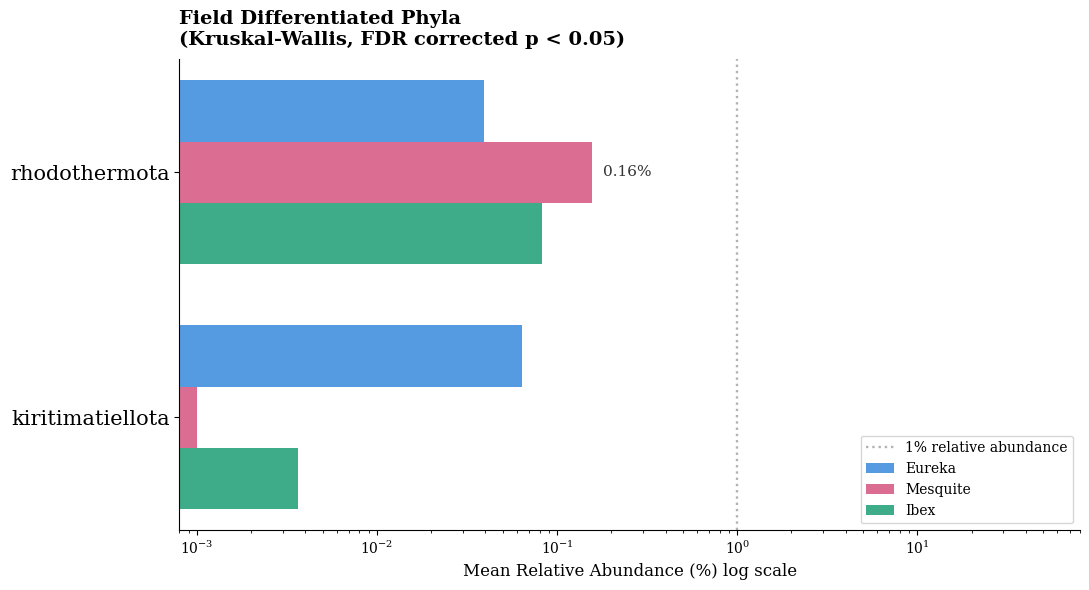

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

# ============================
# QUALITY FILTER THRESHOLDS
# Change these values to adjust stringency
# ============================
MIN_MEAN_READS  = 5.0    # minimum mean reads per sample
MIN_PREVALENCE  = 0.20   # minimum proportion of samples with any reads
MIN_PCT_DATASET = 0.01   # minimum % of total dataset reads

# ============================
# LOAD RELATIVE ABUNDANCE
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

df = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

sample_cols = [s for s in df.columns[1:-7] if "Blank" not in str(s)]
df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ============================
# PHYLUM RENAME MAP
# ============================
rename_map = {
    'actinobacteria':        'actinomycetota',
    'firmicutes':            'bacillota',
    'bacteroidetes':         'bacteroidota',
    'chloroflexi':           'chloroflexota',
    'cyanobacteria':         'cyanobacteriota',
    'proteobacteria':        'pseudomonadota',
    'pseudomonadot':         'pseudomonadota',
    'planctomycetes':        'planctomycetota',
    'gemmatimonadetes':      'gemmatimonadota',
    'verrucomicrobia':       'verrucomicrobiota',
    'acidobacteria':         'acidobacteriota',
    'nitrospirae':           'nitrospirota',
    'chlamydiae':            'chlamydiota',
    'elusimicrobia':         'elusimicrobiota',
    'spirochaetes':          'spirochaetota',
    'tenericutes':           'mycoplasmatota',
    'fusobacteria':          'fusobacteriota',
    'thermodesulfobacteria': 'thermodesulfobacteriota',
    'deinococcus-thermus':   'deinococcota',
    'armatimonadetes':       'armatimonadota',
    'thermotogae':           'thermotogota',
}

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip().replace(rename_map)

# ============================
# FILTER BACTERIA + ARCHAEA
# ============================
micro = df[df["Domain"].isin(["bacteria", "archaea"])].copy()
micro = micro[micro["Phylum"] != "bacteria"]

def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

field_map = {s: get_field(s) for s in sample_cols}

# ============================
# AGGREGATE TO PHYLUM
# ============================
phylum_rel = micro.groupby("Phylum")[sample_cols].sum()

# ============================
# LOAD RAW COUNTS FOR QUALITY CHECK
# ============================
cnt_path = "/content/zotutab_decontam_Final.csv"
raw_cnt  = pd.read_csv(cnt_path, header=None)
df_cnt   = raw_cnt.iloc[2:].copy()
df_cnt.columns = raw_cnt.iloc[1]
df_cnt.reset_index(drop=True, inplace=True)

cnt_cols = [s for s in df_cnt.columns[1:-7] if "Blank" not in str(s)]
df_cnt[cnt_cols] = df_cnt[cnt_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
df_cnt["Domain"] = df_cnt["Domain"].str.lower().str.strip()
df_cnt["Phylum"] = df_cnt["Phylum"].str.lower().str.strip().replace(rename_map)

micro_cnt   = df_cnt[df_cnt["Domain"].isin(["bacteria","archaea"])].copy()
phylum_cnt  = micro_cnt.groupby("Phylum")[cnt_cols].sum()
total_reads = phylum_cnt.values.sum()

# ============================
# KRUSKAL-WALLIS + FDR
# ============================
kw_results = []
for phylum in phylum_rel.index:
    groups = [phylum_rel.loc[phylum, [s for s in sample_cols if field_map[s] == f]]
              for f in ["Eureka", "Mesquite", "Ibex"]]
    if any(len(g) == 0 for g in groups):
        continue
    stat, p = kruskal(*groups)
    kw_results.append({
        "Phylum":        phylum,
        "p_value":       p,
        "Eureka_mean":   groups[0].mean(),
        "Mesquite_mean": groups[1].mean(),
        "Ibex_mean":     groups[2].mean(),
    })

kw_df = pd.DataFrame(kw_results)
kw_df["p_adj"] = multipletests(kw_df["p_value"], method="fdr_bh")[1]
sig_phyla = kw_df[kw_df["p_adj"] < 0.05].copy()

print(f"Significant phyla before quality filtering: {len(sig_phyla)}")

# ============================
# STRICT QUALITY FILTER
# A phylum must PASS ALL THREE checks to be included
# ============================
print("\n" + "="*75)
print(f"QUALITY FILTER  —  must pass ALL three thresholds to be included")
print(f"  Mean reads    ≥ {MIN_MEAN_READS}")
print(f"  Prevalence    ≥ {MIN_PREVALENCE*100:.0f}% of samples")
print(f"  % of dataset  ≥ {MIN_PCT_DATASET}%")
print("="*75)
print(f"\n{'PHYLUM':<35} {'READS':>8} {'PREV':>8} {'%DATA':>8} {'PASS?':>8}")
print("-"*75)

keep = []
for _, row in sig_phyla.iterrows():
    p = row["Phylum"]

    if p not in phylum_cnt.index:
        print(f"{p:<35} {'NOT IN COUNT TABLE':>35} {'FAIL':>8}")
        continue

    counts     = phylum_cnt.loc[p, cnt_cols]
    mean_reads = counts.mean()
    prevalence = (counts > 0).sum() / len(cnt_cols)
    pct_total  = counts.sum() / total_reads * 100

    passes = (
        mean_reads  >= MIN_MEAN_READS  and
        prevalence  >= MIN_PREVALENCE  and
        pct_total   >= MIN_PCT_DATASET
    )

    status = "KEEP" if passes else "REMOVE"
    print(f"{p:<35} {mean_reads:>7.1f}  "
          f"{prevalence*100:>6.1f}%  "
          f"{pct_total:>7.4f}%  "
          f"{status:>8}")

    if passes:
        keep.append(row)

final_df = pd.DataFrame(keep).reset_index(drop=True)
final_df = final_df.sort_values("Ibex_mean", ascending=True).reset_index(drop=True)

print(f"\nFinal phyla after quality filtering: {len(final_df)}")
print(final_df[["Phylum","Eureka_mean","Mesquite_mean",
                "Ibex_mean","p_adj"]].to_string())

# ============================
# FIGURE
# ============================
phyla_s    = final_df["Phylum"].tolist()
eureka_s   = final_df["Eureka_mean"].tolist()
mesquite_s = final_df["Mesquite_mean"].tolist()
ibex_s     = final_df["Ibex_mean"].tolist()

field_colors = {
    'Eureka':   '#378ADD',
    'Mesquite': '#D4537E',
    'Ibex':     '#1D9E75'
}

min_val       = 0.001
eureka_plot   = [max(v, min_val) for v in eureka_s]
mesquite_plot = [max(v, min_val) for v in mesquite_s]
ibex_plot     = [max(v, min_val) for v in ibex_s]

y      = np.arange(len(phyla_s))
height = 0.25

fig, ax = plt.subplots(figsize=(11, max(6, len(phyla_s) * 0.8)))

ax.barh(y + height, eureka_plot,   height,
        label='Eureka',   color=field_colors['Eureka'],   alpha=0.85)
ax.barh(y,           mesquite_plot, height,
        label='Mesquite', color=field_colors['Mesquite'], alpha=0.85)
ax.barh(y - height,  ibex_plot,    height,
        label='Ibex',     color=field_colors['Ibex'],     alpha=0.85)

ax.set_xscale('log')
ax.set_xlim(0.0008, 80)
ax.set_yticks(y)
ax.set_yticklabels(phyla_s, fontsize=15)

ax.axvline(x=1.0, color='gray', linestyle=':',
           linewidth=1.7, alpha=0.6, label='1% relative abundance')

for i, (e, m, ib) in enumerate(zip(eureka_s, mesquite_s, ibex_s)):
    max_val = max(e, m, ib)
    if max_val >= 0.1:
        y_pos = (i + height if max_val == e else
                 i          if max_val == m else
                 i - height)
        ax.text(max_val * 1.15, y_pos,
                f'{max_val:.2f}%',
                va='center', fontsize=11, color='#333333')

ax.set_xlabel('Mean Relative Abundance (%) log scale', fontsize=12)
ax.set_title(
    f'Field Differentiated Phyla \n'
    f'(Kruskal-Wallis, FDR corrected p < 0.05)',
    fontsize=14, fontweight='bold', loc='left', pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, frameon=True, edgecolor='#CCCCCC', loc='lower right')

plt.tight_layout()
plt.show()

#ran august 17 2025

In [13]:
!pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 56.8 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova

# ============================
# LOAD FILE
# already standardised — no rename map needed
# ============================
relabund_path = '/content/zotutab_decontam_RelAbund_Final.csv'

raw_rel = pd.read_csv(relabund_path, header=None)
df_rel  = raw_rel.iloc[2:].copy()
df_rel.columns = raw_rel.iloc[1]
df_rel.reset_index(drop=True, inplace=True)

# ============================
# IDENTIFY SAMPLE COLUMNS
# ============================
tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df_rel.columns[0]

sample_cols = [c for c in df_rel.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df_rel[sample_cols] = df_rel[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df_rel["Domain"] = df_rel["Domain"].str.lower().str.strip()
df_rel["Phylum"] = df_rel["Phylum"].str.lower().str.strip()

# ============================
# FILTER BACTERIA + ARCHAEA
# file already clean — just filter by domain
# ============================
micro = df_rel[
    df_rel["Domain"].isin(["bacteria", "archaea"]) &
    (df_rel["Phylum"] != "bacteria") &
    df_rel["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")

# ============================
# FIELD GROUPS
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

eureka_samples   = [s for s in sample_cols if get_field(s) == "Eureka"]
mesquite_samples = [s for s in sample_cols if get_field(s) == "Mesquite"]
ibex_samples     = [s for s in sample_cols if get_field(s) == "Ibex"]
all_samples      = eureka_samples + mesquite_samples + ibex_samples
shared           = all_samples

metadata = pd.DataFrame(
    {"Field": [get_field(s) for s in all_samples]},
    index=all_samples
)
meta_aln = metadata.copy()

print(f"Eureka: {len(eureka_samples)}  "
      f"Mesquite: {len(mesquite_samples)}  "
      f"Ibex: {len(ibex_samples)}")

# ============================
# BUILD SAMPLE x ZOTU MATRIX
# ============================
zotu_id_col = micro.columns[0]

relabund_t = (
    micro
    .set_index(zotu_id_col)[sample_cols]
    .T
    .fillna(0)
)
relabund_t = relabund_t.loc[
    relabund_t.index.isin(all_samples)
].reindex(all_samples)
relabund_t.index.name   = None
relabund_t.columns.name = None

print(f"Sample x ZOTU matrix: {relabund_t.shape}")

# ============================
# ZOTU-LEVEL RARE/DOMINANT SPLIT
# individual sample maximum per ZOTU
# ============================
zotu_max_sample = relabund_t.max(axis=0)
rare_zotus      = zotu_max_sample[zotu_max_sample <= 1.0].index
dominant_zotus  = zotu_max_sample[zotu_max_sample >  1.0].index

# ============================
# CORE PHYLA
# ≥80% prevalence in all three fields
# ============================
phylum_grouped = micro.groupby("Phylum")[sample_cols].sum()

def get_prev(df, samps):
    return (df[samps] > 0).sum(axis=1) / len(samps)

core_phyla = get_prev(phylum_grouped, eureka_samples).loc[
    (get_prev(phylum_grouped, eureka_samples)   >= 0.80) &
    (get_prev(phylum_grouped, mesquite_samples) >= 0.80) &
    (get_prev(phylum_grouped, ibex_samples)     >= 0.80)
].index.tolist()

zotu_phylum = micro.set_index(zotu_id_col)["Phylum"].to_dict()
core_zotus  = [z for z in relabund_t.columns
               if zotu_phylum.get(z) in core_phyla]

# ============================
# BUILD FOUR SUBSETS
# ============================
all_taxa     = relabund_t.copy()
rare_only    = relabund_t[rare_zotus].copy()
dominant = relabund_t[dominant_zotus].copy()
core_only    = relabund_t[core_zotus].copy()

print(f"\nSubset sizes:")
print(f"  All taxa ZOTUs:     {all_taxa.shape[1]}")
print(f"  Rare only ZOTUs:    {rare_only.shape[1]}")
print(f"  Dominant ZOTUs: {dominant.shape[1]}")
print(f"  Core only ZOTUs:    {core_only.shape[1]}")
print(f"  Core phyla used:    {len(core_phyla)}")

# ============================
# PCoA FUNCTION
# ============================
def pcoa(dist_arr):
    D2         = dist_arr ** 2
    row_mean   = D2.mean(axis=1, keepdims=True)
    col_mean   = D2.mean(axis=0, keepdims=True)
    grand_mean = D2.mean()
    B          = -0.5 * (D2 - row_mean - col_mean + grand_mean)
    eigvals, eigvecs = np.linalg.eigh(B)
    idx     = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    pos     = eigvals > 0
    coords  = eigvecs[:, pos] * np.sqrt(eigvals[pos])
    var_exp = eigvals[pos] / eigvals[pos].sum() * 100
    return coords, var_exp

# ============================
# BRAY-CURTIS DISTANCE
# ============================
def bray_curtis_dm(df):
    arr = df.values.astype(float)
    bc  = squareform(pdist(arr, metric="braycurtis"))
    return np.nan_to_num(bc, nan=1.0)

print("\nComputing distance matrices...")
dm_all      = bray_curtis_dm(all_taxa)
dm_rare     = bray_curtis_dm(rare_only)
dm_no_rare  = bray_curtis_dm(dominant)
dm_core     = bray_curtis_dm(core_only)
print("Done.")

print("Running PCoA...")
coords_all,     var_all     = pcoa(dm_all)
coords_rare,    var_rare    = pcoa(dm_rare)
coords_no_rare, var_no_rare = pcoa(dm_no_rare)
coords_core,    var_core    = pcoa(dm_core)
print("Done.")

print("\nVariance explained:")
for label, var in [
    ("All taxa",     var_all),
    ("Rare only",    var_rare),
    ("Dominant", var_no_rare),
    ("Core only",    var_core),
]:
    print(f"  [{label:<15}]  PCo1: {var[0]:.1f}%  PCo2: {var[1]:.1f}%")

# ============================
# PERMANOVA — Anderson (2001) verified formula
# ============================
def run_permanova(dm_arr, grouping, label, n_perm=999):
    groups  = np.array(grouping)
    n       = len(groups)
    unique  = np.unique(groups)

    ss_total  = np.sum(dm_arr ** 2) / n
    ss_within = sum(
        np.sum(dm_arr[np.ix_(np.where(groups == g)[0],
                              np.where(groups == g)[0])] ** 2) /
        len(np.where(groups == g)[0])
        for g in unique if len(np.where(groups == g)[0]) > 1
    )
    r2 = (ss_total - ss_within) / ss_total if ss_total > 0 else 0

    dm_obj = DistanceMatrix(dm_arr, ids=all_samples)
    meta   = pd.Series(groups, index=all_samples, name="Group")
    result = permanova(dm_obj, meta,
                       column="Group", permutations=n_perm)
    p_val  = result["p-value"]
    f_stat = result["test statistic"]

    print(f"  {label:<20}  R² = {r2*100:.1f}%  "
          f"F = {f_stat:.2f}  p = {p_val:.3f}")
    return r2, p_val, f_stat

field_groups_list = [get_field(s) for s in all_samples]

print("\nPERMANOVA — Field identity (Anderson 2001 R²):")
print("-" * 55)
for dm_arr, label in [
    (dm_all,     "All taxa"),
    (dm_rare,    "Rare only"),
    (dm_no_rare, "Dominant"),
    (dm_core,    "Core only"),
]:
    run_permanova(dm_arr, field_groups_list, label)

Prokaryotic ZOTUs: 6014
Eureka: 24  Mesquite: 18  Ibex: 10
Sample x ZOTU matrix: (52, 6014)

Subset sizes:
  All taxa ZOTUs:     6014
  Rare only ZOTUs:    5754
  Dominant ZOTUs: 260
  Core only ZOTUs:    5936
  Core phyla used:    19

Computing distance matrices...
Done.
Running PCoA...
Done.

Variance explained:
  [All taxa       ]  PCo1: 15.0%  PCo2: 9.0%
  [Rare only      ]  PCo1: 8.8%  PCo2: 6.2%
  [Dominant       ]  PCo1: 21.2%  PCo2: 10.4%
  [Core only      ]  PCo1: 15.1%  PCo2: 9.1%

PERMANOVA — Field identity (Anderson 2001 R²):
-------------------------------------------------------
  All taxa              R² = 14.7%  F = 4.23  p = 0.001
  Rare only             R² = 11.5%  F = 3.17  p = 0.001
  Dominant              R² = 17.1%  F = 5.05  p = 0.001
  Core only             R² = 14.8%  F = 4.24  p = 0.001


In [4]:
!pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 28.9 MB/s eta 0:00:00


Prokaryotic ZOTUs: 6014
Eureka: 24  Mesquite: 18  Ibex: 10
Grain size assessed: 43/52 samples (9 excluded from grain-size tests)
Grain size classes: {'Medium (upper)': 17, 'Medium (lower)': 12, 'Coarse (lower)': 9, 'Coarse (upper)': 5}
Sample x ZOTU matrix: (52, 6014)

Subset sizes:
  All taxa:     6014
  Rare only:    5754
  Dominant:     260
  Core only:    5936
  Core phyla:   19

Computing distance matrices...
Done.

Running PERMANOVA + bootstrap: All taxa...

Running PERMANOVA + bootstrap: Rare only...

Running PERMANOVA + bootstrap: Dominant...

Running PERMANOVA + bootstrap: Core only...

PERMANOVA RESULTS  (R2 with bootstrapped 95% CI, 1000 resamples)
   Subset   Variable  n     R2  R2_CI_low  R2_CI_high     F     p Sig  PERMDISP_p
 All taxa      Field 52 0.1472     0.1433      0.2253 4.231 0.001  **       0.456
 All taxa Morphology 52 0.1336     0.1239      0.2507 1.418 0.004  **       0.001
 All taxa  GrainSize 43 0.1369     0.1390      0.2580 2.063 0.001  **       0.176
Rare

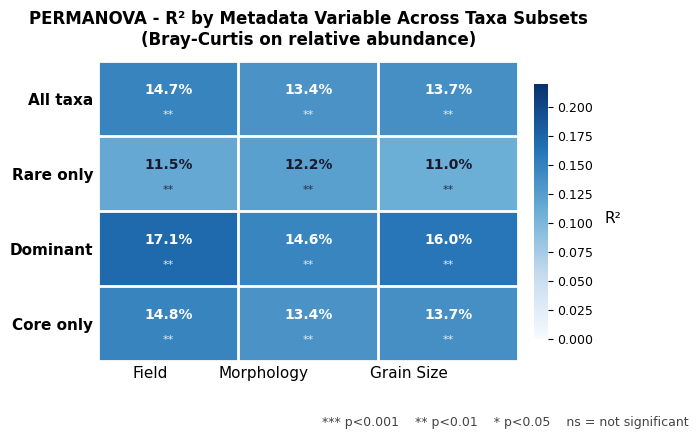

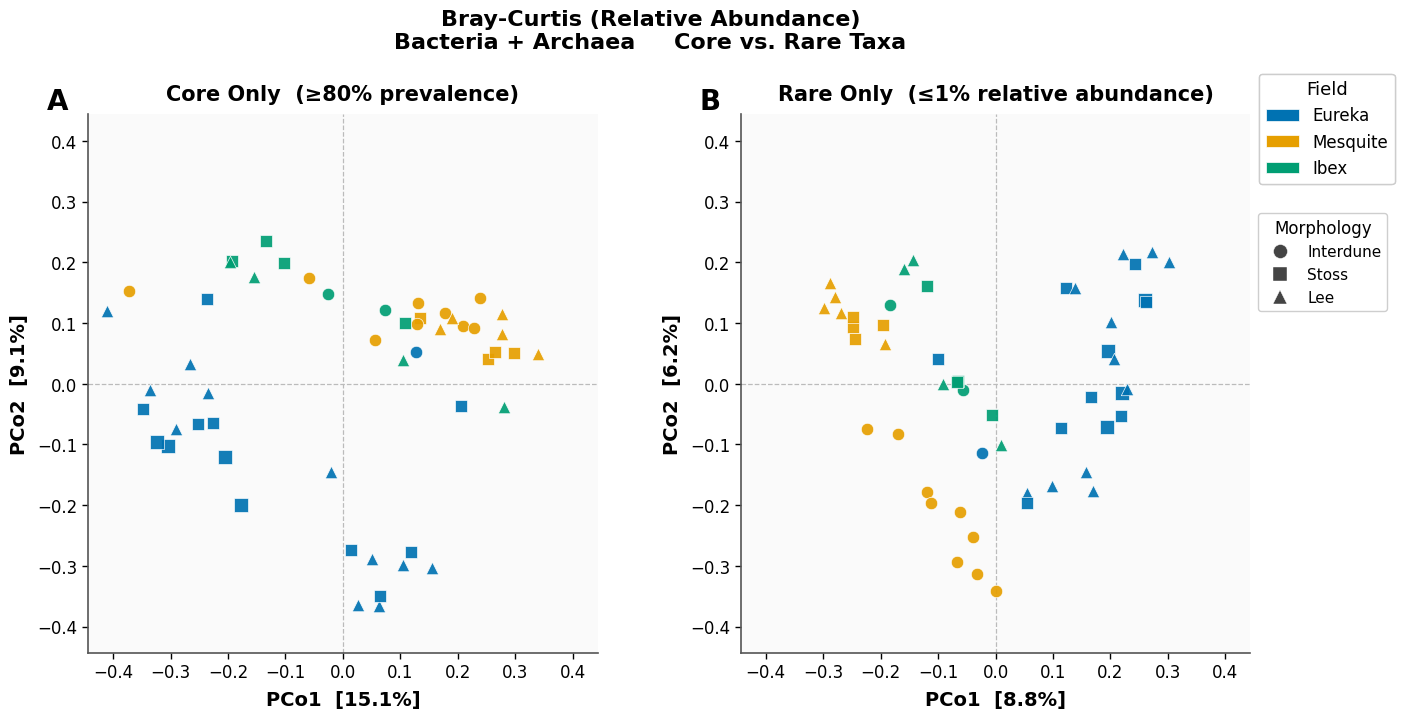

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova, permdisp
#SUGARBEAR
np.random.seed(42)

# ============================
# PATHS
# ============================
REL_PATH  = "/content/zotutab_decontam_RelAbund_Final.csv"
META_PATH = "/content/PERM_metadata.csv"

# ============================
# LOAD RELATIVE ABUNDANCE
# ============================
raw = pd.read_csv(REL_PATH, header=None)
df  = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

# ============================
# FILTER BACTERIA + ARCHAEA
# ============================
micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")

# ============================
# LOAD METADATA
# GrainSize: FOUR half-phi Wentworth classes, encoded as the
# phi value of each class's geometric-mean diameter
# (0.26, 0.76, 1.26, 1.76). Treated as an ORDERED CATEGORICAL
# factor -- skbio's one-way PERMANOVA is a categorical test.
# Samples with no grain size assessment are EXCLUDED from
# grain-size tests (no imputation): the missing samples are
# concentrated in wet interdune sites at Mesquite, so
# median-filling would invent data for a non-random subset.
# ============================
meta = pd.read_csv(META_PATH).rename(
    columns={"Sample Name:": "SampleID"})
meta["SampleID"] = meta["SampleID"].str.strip()
meta = meta.set_index("SampleID")

GRAIN_LABELS = {
    "0.26": "Coarse (upper)",   # 0.7-1.0 mm
    "0.76": "Coarse (lower)",   # 0.5-0.7 mm
    "1.26": "Medium (upper)",   # 0.35-0.50 mm
    "1.76": "Medium (lower)",   # 0.25-0.35 mm
}

# ============================
# FIELD GROUPS
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

eureka_samples   = [s for s in sample_cols if get_field(s) == "Eureka"]
mesquite_samples = [s for s in sample_cols if get_field(s) == "Mesquite"]
ibex_samples     = [s for s in sample_cols if get_field(s) == "Ibex"]
all_samples      = eureka_samples + mesquite_samples + ibex_samples
shared           = all_samples

metadata = pd.DataFrame(
    {"Field": [get_field(s) for s in all_samples]},
    index=all_samples
)

shared_meta = meta.loc[meta.index.isin(all_samples)]
meta_aln    = shared_meta.reindex(all_samples)
meta_aln["Morphology"] = meta_aln["Morphology"].str.strip()

# GrainSize -> ordered categorical class labels; blanks stay NaN
gs_raw = meta_aln["GrainSize"].astype(str).str.strip()
meta_aln["GrainSize"] = gs_raw.map(GRAIN_LABELS)  # unmapped -> NaN

n_gs = meta_aln["GrainSize"].notna().sum()
print(f"Eureka: {len(eureka_samples)}  "
      f"Mesquite: {len(mesquite_samples)}  "
      f"Ibex: {len(ibex_samples)}")
print(f"Grain size assessed: {n_gs}/{len(all_samples)} samples "
      f"({len(all_samples) - n_gs} excluded from grain-size tests)")
print("Grain size classes:",
      meta_aln["GrainSize"].value_counts().to_dict())

# ============================
# BUILD SAMPLE x ZOTU MATRIX
# ============================
relabund_t = (
    micro.set_index(zotu_col)[sample_cols]
    .T.fillna(0)
)
relabund_t = relabund_t.reindex(all_samples)
relabund_t.index.name   = None
relabund_t.columns.name = None

print(f"Sample x ZOTU matrix: {relabund_t.shape}")

# ============================
# RARE / DOMINANT SPLIT
# ============================
zotu_max       = relabund_t.max(axis=0)
rare_zotus     = zotu_max[zotu_max <= 1.0].index
dominant_zotus = zotu_max[zotu_max >  1.0].index

# ============================
# CORE PHYLA (>=80% prevalence in all three fields)
# ============================
phylum_grouped = micro.groupby("Phylum")[sample_cols].sum()

def get_prev(df, samps):
    return (df[samps] > 0).sum(axis=1) / len(samps)

core_phyla = get_prev(phylum_grouped, eureka_samples).loc[
    (get_prev(phylum_grouped, eureka_samples)   >= 0.80) &
    (get_prev(phylum_grouped, mesquite_samples) >= 0.80) &
    (get_prev(phylum_grouped, ibex_samples)     >= 0.80)
].index.tolist()

zotu_phylum = micro.set_index(zotu_col)["Phylum"].to_dict()
core_zotus  = [z for z in relabund_t.columns
               if zotu_phylum.get(z) in core_phyla]

# ============================
# FOUR SUBSETS
# ============================
all_taxa  = relabund_t.copy()
rare_only = relabund_t[rare_zotus].copy()
dominant  = relabund_t[dominant_zotus].copy()
core_only = relabund_t[core_zotus].copy()

print(f"\nSubset sizes:")
print(f"  All taxa:     {all_taxa.shape[1]}")
print(f"  Rare only:    {rare_only.shape[1]}")
print(f"  Dominant:     {dominant.shape[1]}")
print(f"  Core only:    {core_only.shape[1]}")
print(f"  Core phyla:   {len(core_phyla)}")

# ============================
# BRAY-CURTIS DISTANCE
# ============================
def bray_curtis_dm(df):
    # df: samples as rows, ZOTUs as columns (relative abundances)
    arr = df.values.astype(float)                     # pull out the raw numbers as a float array
    bc  = squareform(pdist(arr, metric="braycurtis")) # pdist computes Bray-Curtis between every PAIR
                                                      # of rows (samples); squareform reshapes that
                                                      # list of pairs into a full n x n symmetric matrix
                                                      # with zeros on the diagonal
    return np.nan_to_num(bc, nan=1.0)                 # if two samples are both all-zero, Bray-Curtis
                                                      # is 0/0 = NaN; replace with 1.0 (maximally
                                                      # dissimilar) so downstream math doesn't break

print("\nComputing distance matrices...")
# One distance matrix per taxa subset. Same samples (rows) in all
# four -- only the ZOTU columns used to measure dissimilarity differ.
dist_all     = bray_curtis_dm(all_taxa)    # distances using every prokaryotic ZOTU
dist_rare    = bray_curtis_dm(rare_only)   # distances using only ZOTUs whose max abundance <= 1%
dist_no_rare = bray_curtis_dm(dominant)    # distances using only ZOTUs whose max abundance  > 1%
dist_core    = bray_curtis_dm(core_only)   # distances using only ZOTUs in core phyla (>=80% prevalence)

# Wrap each plain numpy matrix in skbio's DistanceMatrix object,
# attaching sample IDs to rows/columns. skbio's permanova/permdisp
# require this object, and the IDs let us slice by sample name later.
dm_all     = DistanceMatrix(dist_all,     ids=all_samples)
dm_rare    = DistanceMatrix(dist_rare,    ids=all_samples)
dm_no_rare = DistanceMatrix(dist_no_rare, ids=all_samples)
dm_core    = DistanceMatrix(dist_core,    ids=all_samples)
print("Done.")

# ============================
# VERIFIED R2 FORMULA -- Anderson (2001)
# ============================
def manual_r2(d, groups):
    # skbio's permanova returns F and p but NOT R2, so we compute
    # R2 ourselves from the distance matrix, following Anderson (2001):
    #   R2 = SS_among / SS_total = (SS_total - SS_within) / SS_total
    g  = np.array(groups)          # group label for each sample (e.g. field name)
    n  = len(g)                    # total number of samples
    ss_t = np.sum(d ** 2) / n      # TOTAL sum of squares: sum of ALL squared
                                   # pairwise distances divided by n
                                   # (Anderson's trick: SS can be computed from
                                   # distances alone, no coordinates needed.
                                   # Note: d contains each pair twice (full
                                   # symmetric matrix), which is why we divide
                                   # by n rather than n*2 -- the doubling and
                                   # the standard /2 cancel out.)
    ss_w = sum(                    # WITHIN-group sum of squares: same formula,
        np.sum(d[np.ix_(np.where(g == x)[0],          # but restricted to the sub-matrix of
                         np.where(g == x)[0])] ** 2) / # distances between samples in the SAME
        len(np.where(g == x)[0])                       # group, divided by that group's size,
        for x in np.unique(g)                          # summed over every group...
        if len(np.where(g == x)[0]) > 1                # ...skipping groups of 1 (a single sample
    )                                                  # has no within-group distances)
    # R2 = fraction of total variation that is NOT within groups,
    # i.e. the fraction explained by the grouping variable
    return (ss_t - ss_w) / ss_t if ss_t > 0 else np.nan

def sig_str(p):
    # Convert a p-value into the usual star notation for tables/figures
    try:
        p = float(p)
        return "***" if p < 0.001 else "**" if p < 0.01 \
               else "*" if p < 0.05 else "ns"
    except:
        return ""                  # non-numeric input (e.g. "N/A") -> empty string

# ============================
# BOOTSTRAPPED 95% CI ON R2
# Resamples samples (rows) with replacement, recomputes
# Bray-Curtis + Anderson (2001) R2 each draw. Draws where a
# grouping collapses below two groups are redrawn.
# ============================
N_BOOT = 1000                        # number of bootstrap resamples
rng = np.random.default_rng(42)      # seeded random generator -> results reproducible run-to-run

def bootstrap_r2_ci(abund_df, groups, n_boot=N_BOOT, ci=95):
    # The point R2 above is a single number with no sense of how
    # much it would wobble with different samples. The bootstrap
    # answers that: pretend the dataset is the population, redraw
    # datasets of the same size from it (with replacement), and see
    # how R2 varies across those redraws.
    g   = np.asarray(groups)             # group labels, aligned to rows of abund_df
    n   = len(abund_df)                  # number of samples
    arr = abund_df.values.astype(float)  # abundance table as a raw array
    boot_r2 = np.empty(n_boot)           # storage for the n_boot R2 values
    k = 0
    while k < n_boot:
        bs = rng.integers(0, n, size=n)  # draw n row indices WITH replacement --
                                         # some samples appear twice+, some not at all
        gb = g[bs]                       # group labels of the drawn samples
        if len(np.unique(gb)) < 2:       # if the draw happens to contain only ONE
            continue                     # group, R2 is undefined -> throw it back
                                         # and redraw (doesn't count toward n_boot)
        d = squareform(pdist(arr[bs], metric="braycurtis"))
                                         # recompute Bray-Curtis ON THE RESAMPLED ROWS.
                                         # This must be recomputed (not sliced from the
                                         # original matrix) because duplicated samples
                                         # create new zero-distance pairs
        d = np.nan_to_num(d, nan=1.0)    # same NaN guard as bray_curtis_dm
        boot_r2[k] = manual_r2(d, gb)    # R2 of this bootstrap replicate
        k += 1
    # The middle 95% of the bootstrap R2 distribution IS the CI
    # ("percentile bootstrap"): for ci=95 take the 2.5th and 97.5th
    # percentiles
    lo = np.percentile(boot_r2, (100 - ci) / 2)
    hi = np.percentile(boot_r2, 100 - (100 - ci) / 2)
    return lo, hi

# ============================
# PERMANOVA + PERMDISP + BOOTSTRAP
# All three variables are categorical:
#   Field (3 groups), Morphology (3 base positions),
#   GrainSize (4 ordered half-phi classes).
# PERMDISP now runs for GrainSize too.
# GrainSize tests use only samples with an assessment.
# ============================
cat_vars = ["Field", "Morphology", "GrainSize"]   # the three tested variables --
                                                  # all categorical now that grain size
                                                  # is its four half-phi classes

SUBSETS = [
    # (label for output table, distance matrix, abundance table)
    # The abundance table rides along ONLY for the bootstrap, which
    # needs raw abundances to recompute distances per resample
    ("All taxa",  dm_all,     all_taxa),
    ("Rare only", dm_rare,    rare_only),
    ("Dominant",  dm_no_rare, dominant),
    ("Core only", dm_core,    core_only),
]

# The sample IDs that HAVE a grain size assessment (the 9 blanks --
# 9 interdune-heavy samples are left out).
# Built once, reused for every subset.
gs_ids = [s for s in all_samples
          if pd.notna(meta_aln.loc[s, "GrainSize"])]

records = []                              # one dict per (subset x variable) test
for subset_label, dm, abund in SUBSETS:   # outer loop: 4 taxa subsets
    print(f"\nRunning PERMANOVA + bootstrap: {subset_label}...")
    for var in cat_vars:                  # inner loop: 3 variables -> 12 tests total
        if var == "GrainSize":
            ids = gs_ids                  # grain size: only assessed samples (n ~ 53)
        else:
            ids = all_samples             # field & morphology: every sample

        grp   = meta_aln.loc[ids, var]    # group label per included sample
        dm_v  = dm.filter(ids)            # slice the DistanceMatrix down to those
                                          # samples. Valid without recomputing:
                                          # Bray-Curtis is pairwise, so removing
                                          # samples doesn't change the distances
                                          # between the ones that remain
        d_arr = dm_v.data                 # the sliced matrix as plain numpy (for manual_r2)
        ab_v  = abund.loc[ids]            # matching rows of the abundance table (for bootstrap)

        # --- the actual significance test ---
        res_p = permanova(dm_v, grp, permutations=999)
                                          # one-way PERMANOVA: shuffles group labels
                                          # 999 times; p = how often shuffled data
                                          # separates groups as well as the real labels
        r2    = manual_r2(d_arr, grp.values)   # effect size (skbio doesn't provide it)
        p_val = float(res_p["p-value"])        # pull p out of skbio's result Series
        f_val = float(res_p["test statistic"]) # pull pseudo-F out likewise

        # --- uncertainty on the effect size ---
        ci_lo, ci_hi = bootstrap_r2_ci(ab_v, grp.values)   # 95% CI via 1000 resamples

        # --- dispersion check ---
        try:
            res_d  = permdisp(dm_v, grp, permutations=999)
                                          # PERMDISP asks: do groups differ in SPREAD
                                          # (distance to their own centroid)? If yes,
                                          # part of the PERMANOVA signal may be
                                          # dispersion, not location. Runs for all
                                          # three variables now, grain size included
            disp_p = float(res_d["p-value"])
        except Exception:
            disp_p = np.nan               # if PERMDISP fails for any reason, record N/A
                                          # rather than crashing the whole loop

        # --- one row of the results table ---
        records.append({
            "Subset":     subset_label,
            "Variable":   var,
            "n":          len(ids),       # sample count used for THIS test
                                          # (differs for grain size vs the others)
            "R2":         round(r2, 4),
            "R2_CI_low":  round(ci_lo, 4),
            "R2_CI_high": round(ci_hi, 4),
            "F":          round(f_val, 3),
            "p":          round(p_val, 4),
            "Sig":        sig_str(p_val),
            "PERMDISP_p": round(disp_p, 4)
                         if not np.isnan(disp_p) else "N/A",
        })

results_df = pd.DataFrame(records)        # 12 rows: 4 subsets x 3 variables

print("\n" + "=" * 90)
print(f"PERMANOVA RESULTS  (R2 with bootstrapped 95% CI, {N_BOOT} resamples)")
print("=" * 90)
print(results_df.to_string(index=False))

# Save the full table (point R2, CIs, F, p, PERMDISP p, n) so the
# numbers can be copied into the manuscript / supplement directly
results_df.to_csv("permanova_results_with_CIs.csv", index=False)
print("\nSaved: permanova_results_with_CIs.csv")

# ============================
# HEATMAP -- 3 variables
# ============================
SUBSET_ORDER = ["All taxa", "Rare only", "Dominant", "Core only"]
VAR_ORDER    = ["Field", "Morphology", "GrainSize"]
VAR_LABELS   = ["Field", "Morphology", "Grain Size"]

n_subsets = len(SUBSET_ORDER)
n_vars    = len(VAR_ORDER)

r2_mat = np.zeros((n_subsets, n_vars))
p_mat  = np.ones((n_subsets, n_vars))

for si, subset in enumerate(SUBSET_ORDER):
    for vi, var in enumerate(VAR_ORDER):
        row = results_df[
            (results_df["Subset"]   == subset) &
            (results_df["Variable"] == var)
        ]
        if len(row):
            r2_mat[si, vi] = row["R2"].values[0]
            p_mat[si,  vi] = row["p"].values[0]

cmap = LinearSegmentedColormap.from_list(
    "r2map", ["#f7fbff","#c6dbef","#6baed6",
              "#2171b5","#08306b"])

fig_h, ax_h = plt.subplots(figsize=(8, 5))
fig_h.patch.set_facecolor("white")
fig_h.subplots_adjust(bottom=0.28, top=0.88,
                       left=0.22, right=0.86)

im = ax_h.imshow(r2_mat, cmap=cmap, aspect="auto",
                 vmin=0, vmax=max(0.22, r2_mat.max() + 0.02))

for si in range(n_subsets):
    for vi in range(n_vars):
        r2 = r2_mat[si, vi]
        p  = p_mat[si,  vi]
        tc = "white" if r2 > 0.13 else "#1a1a2e"
        ax_h.text(vi, si - 0.12, f"{r2*100:.1f}%",
                  ha="center", va="center",
                  fontsize=10, fontweight="bold", color=tc)
        ax_h.text(vi, si + 0.22, sig_str(p),
                  ha="center", va="center",
                  fontsize=8, color=tc, alpha=0.85)

for x in np.arange(-0.5, n_vars, 1):
    ax_h.axvline(x, color="white", lw=2)
for y in np.arange(-0.5, n_subsets, 1):
    ax_h.axhline(y, color="white", lw=2)

ax_h.set_xticks(range(n_vars))
ax_h.set_xticklabels(VAR_LABELS, fontsize=11, ha="right")
ax_h.set_yticks(range(n_subsets))
ax_h.set_yticklabels(SUBSET_ORDER, fontsize=11,
                     fontweight="bold")
ax_h.tick_params(length=0)
for sp in ax_h.spines.values():
    sp.set_visible(False)

ax_h.set_title(
    "PERMANOVA - R² by Metadata Variable Across Taxa Subsets\n"
    "(Bray-Curtis on relative abundance)",
    fontsize=12, fontweight="bold", pad=12)

cb = fig_h.colorbar(im, ax=ax_h, shrink=0.85,
                     pad=0.03, aspect=18)
cb.set_label("R²", fontsize=11, labelpad=8,
             rotation=0, ha="left")
cb.ax.tick_params(labelsize=9)
cb.outline.set_visible(False)

fig_h.text(0.5, 0.15,
           "*** p<0.001    ** p<0.01    * p<0.05"
           "    ns = not significant",
           fontsize=9, color="#444444",
           transform=fig_h.transFigure)

plt.show()

# ============================
# PCoA -- Core Only (A) and Rare Only (B)  [unchanged]
# ============================
def pcoa(dist_arr):
    D2         = dist_arr ** 2
    row_mean   = D2.mean(axis=1, keepdims=True)
    col_mean   = D2.mean(axis=0, keepdims=True)
    grand_mean = D2.mean()
    B          = -0.5 * (D2 - row_mean - col_mean + grand_mean)
    eigvals, eigvecs = np.linalg.eigh(B)
    idx     = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    pos     = eigvals > 0
    coords  = eigvecs[:, pos] * np.sqrt(eigvals[pos])
    var_exp = eigvals[pos] / eigvals[pos].sum() * 100
    return coords, var_exp

coords_core, var_core = pcoa(bray_curtis_dm(core_only))
coords_rare, var_rare = pcoa(bray_curtis_dm(rare_only))

FIELD_COLORS = {
    "Eureka":   "#0072B2",
    "Mesquite": "#E69F00",
    "Ibex":     "#009E73",
}

MORPH_STYLE = {
    "Interdune":        ("o",  80),
    "Stoss":            ("s",  75),
    "Lee":              ("^",  80),
    "Stoss, Depth":     ("s",  75),
    "Stoss , Depth":    ("s",  75),
    "Interdune, Depth": ("o",  75),
    "Stoss, Star":      ("s", 110),
    "Stoss , Star":     ("s", 110),
    "Lee, Star":        ("^",  80),
    "Stoss, Crest":     ("s",  75),
}

fields = [get_field(s) for s in shared]
morphs = meta_aln["Morphology"].fillna(
    "Interdune").str.strip().tolist()

fig_p, axes = plt.subplots(
    1, 2, figsize=(15, 7),
    gridspec_kw={"wspace": 0.28})
fig_p.patch.set_facecolor("white")

panel_data = [
    (axes[0], coords_core, var_core,
     "Core Only  (≥80% prevalence)", "A"),
    (axes[1], coords_rare, var_rare,
     "Rare Only  (≤1% relative abundance)", "B"),
]

all_x = np.concatenate([coords_core[:,0], coords_rare[:,0]])
all_y = np.concatenate([coords_core[:,1], coords_rare[:,1]])
pad  = 0.08
half = max(abs(all_x).max(), abs(all_y).max()) * (1 + pad)

for ax, coords, var_exp, title, lbl in panel_data:
    n_plot = min(len(shared), coords.shape[0])
    for i in range(n_plot):
        fc     = FIELD_COLORS.get(fields[i], "gray")
        mk, sz = MORPH_STYLE.get(morphs[i], ("o", 80))
        ax.scatter(coords[i,0], coords[i,1],
                   color=fc, marker=mk, s=sz,
                   edgecolors="white", linewidths=0.5,
                   alpha=0.92, zorder=3)

    ax.axhline(0, color="#bbbbbb", lw=0.9, ls="--", zorder=1)
    ax.axvline(0, color="#bbbbbb", lw=0.9, ls="--", zorder=1)
    ax.set_xlabel(f"PCo1  [{var_exp[0]:.1f}%]",
                  fontsize=14, fontweight="bold", labelpad=6)
    ax.set_ylabel(f"PCo2  [{var_exp[1]:.1f}%]",
                  fontsize=14, fontweight="bold", labelpad=6)
    ax.set_title(title, fontsize=15, fontweight="bold", pad=10)
    ax.text(-0.08, 1.05, lbl, transform=ax.transAxes,
            fontsize=20, fontweight="bold", va="top")
    ax.tick_params(labelsize=12, length=4, width=1.0)
    ax.set_facecolor("#fafafa")
    ax.set_xlim(-half, half)
    ax.set_ylim(-half, half)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    for sp in ["bottom", "left"]:
        ax.spines[sp].set_color("#555555")
        ax.spines[sp].set_linewidth(1.2)

field_handles = [
    mpatches.Patch(facecolor=c, edgecolor="white",
                   lw=0.5, label=f)
    for f, c in FIELD_COLORS.items()
]

morph_legend_items = [
    ("Interdune", "o", 10),
    ("Stoss",     "s", 10),
    ("Lee",       "^", 10),
]
morph_handles = [
    plt.Line2D([0],[0], marker=mk, color="w",
               markerfacecolor="#444444",
               markeredgecolor="white",
               markeredgewidth=0.3,
               markersize=ms, label=mo, linewidth=0)
    for mo, mk, ms in morph_legend_items
]

leg1 = fig_p.legend(
    handles=field_handles, title="Field",
    loc="upper left", bbox_to_anchor=(.9, 0.95),
    frameon=True, framealpha=0.95, edgecolor="#cccccc",
    fontsize=12, title_fontsize=13)
leg2 = fig_p.legend(
    handles=morph_handles, title="Morphology",
    loc="upper left", bbox_to_anchor=(.9, 0.75),
    frameon=True, framealpha=0.95, edgecolor="#cccccc",
    fontsize=11, title_fontsize=12)
fig_p.add_artist(leg1)

fig_p.suptitle(
    "Bray-Curtis (Relative Abundance)\n"
    "Bacteria + Archaea     Core vs. Rare Taxa",
    fontsize=16, fontweight="bold", y=1.03)

plt.show()

In [16]:
from skbio.stats.distance import permdisp, DistanceMatrix
import pandas as pd
import numpy as np

# using your existing dm_all distance matrix
# and meta_aln metadata with Morphology column

morph_groups = meta_aln["Morphology"].fillna(
    "Interdune").str.strip()

# simplify compound morphologies to base position
morph_simple = morph_groups.copy()
morph_simple = morph_simple.replace({
    "Stoss, Star":  "Stoss",
    "Stoss , Star": "Stoss",
    "Lee, Star":    "Lee",
    "Stoss, Crest": "Stoss",
})

# run permdisp
result = permdisp(dm_all, morph_simple, permutations=999)
print(result)

# get mean distances to centroid per group
print("\nMean distance to centroid by morphology:")
bc_arr = np.array(dm_all.data)
ids    = list(dm_all.ids)

for morph in ["Interdune", "Stoss", "Lee"]:
    idx = [i for i, s in enumerate(ids)
           if morph_simple.loc[s] == morph]
    if len(idx) < 2:
        continue
    sub = bc_arr[np.ix_(idx, idx)]
    mean_dist = sub.sum(axis=1) / (2 * len(idx))
    print(f"  {morph:<12} n={len(idx):>3}  "
          f"mean dist to centroid = {mean_dist.mean():.4f}  "
          f"SD = {mean_dist.std():.4f}")

method name               PERMDISP
test statistic name        F-value
sample size                     52
number of groups                 3
test statistic            4.148522
p-value                      0.023
number of permutations         999
Name: PERMDISP results, dtype: object

Mean distance to centroid by morphology:
  Interdune    n= 12  mean dist to centroid = 0.3850  SD = 0.0111
  Stoss        n= 20  mean dist to centroid = 0.3523  SD = 0.0143
  Lee          n= 20  mean dist to centroid = 0.3513  SD = 0.0134


In [17]:
#CORE,DOMINANT,Rare Along transect

import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# ============================
# LOAD COORDINATE FILE
# ============================
coord_path = "DEVA_Sample_Info.csv"
coords_raw = pd.read_csv(coord_path)

# clean sample names — convert dash to dot to match OTU table
def parse_sample_name(full_name):
    full_name = str(full_name).strip()
    parts     = full_name.split()
    code      = parts[-1]
    return code.replace("-", ".")

coords_raw["SampleID"] = coords_raw["Sample Name:"].apply(
    parse_sample_name)

# clean coordinates
coords_raw["Lat"] = pd.to_numeric(
    coords_raw["Latitude (°N)"],  errors="coerce")
coords_raw["Lon"] = pd.to_numeric(
    coords_raw["Longitude (°W)"], errors="coerce")

# longitude stored as positive W — make negative
coords_raw["Lon"] = coords_raw["Lon"].apply(
    lambda x: -abs(x) if pd.notna(x) else x)

# ============================
# CHECK FOR DUPLICATES
# ============================
print("All parsed sample IDs:")
print(coords_raw[["Sample Name:", "SampleID",
                   "Lat", "Lon"]].to_string())

dupes = coords_raw["SampleID"][
    coords_raw["SampleID"].duplicated()].tolist()
print(f"\nDuplicate SampleIDs: {dupes}")

# ============================
# KEEP FIRST OCCURRENCE
# drop duplicates before building map
# ============================
coords_clean = coords_raw.dropna(
    subset=["Lat", "Lon"]).drop_duplicates(
    subset="SampleID", keep="first")

coord_map = coords_clean.set_index("SampleID")[
    ["Lat", "Lon"]].to_dict(orient="index")

print(f"\nCoordinates loaded for {len(coord_map)} unique samples")

# spot check
print("\nSpot check:")
for s in ["MF.4B", "MF.12A", "ED.01A", "IX.1B"]:
    print(f"  {s}: {coord_map.get(s, 'MISSING')}")

# ============================
# HAVERSINE DISTANCE FUNCTION
# returns distance in metres
# ============================
def haversine_m(lat1, lon1, lat2, lon2):
    R    = 6371000
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a    = (sin(dphi/2)**2 +
            cos(phi1) * cos(phi2) * sin(dlam/2)**2)
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# ============================
# TEST DISTANCE CALCULATION
# ============================
print("\nDistance test — first to last Mesquite sample:")
mesquite = [
    "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
    "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
]

anchor = coord_map.get("MF.12A")
if anchor:
    for s in mesquite:
        c = coord_map.get(s)
        if c:
            d = haversine_m(anchor["Lat"], anchor["Lon"],
                            c["Lat"], c["Lon"])
            print(f"  {s}: {d:.1f} m")
        else:
            print(f"  {s}: MISSING coords")

All parsed sample IDs:
                  Sample Name: SampleID        Lat        Lon
0    MESQUITE FLATS SAND MF-4B    MF.4B  36.616170 -117.11751
1    MESQUITE FLATS SAND MF-5B    MF.5B  36.614740 -117.11369
2    MESQUITE FLATS SAND MF-6B    MF.6B  36.614722 -117.11330
3    MESQUITE FLATS SAND MF-7B    MF.7B  36.613910 -117.11299
4    MESQUITE FLATS SAND MF-8B    MF.8B  36.613910 -117.11299
5   MESQUITE FLATS SAND MF-11A   MF.11A  36.615590 -117.12206
6   MESQUITE FLATS SAND MF-12A   MF.12A  36.615590 -117.12206
7   MESQUITE FLATS SAND MF-13A   MF.13A  36.614190 -117.12077
8   MESQUITE FLATS SAND MF-14B   MF.14B  36.613910 -117.12043
9   MESQUITE FLATS SAND MF-15A   MF.15A  36.613540 -117.12106
10  MESQUITE FLATS SAND MF-16A   MF.16A  36.612890 -117.11925
11  MESQUITE FLATS SAND MF-17A   MF.17A  36.612530 -117.11896
12  MESQUITE FLATS SAND MF-18B   MF.18B  36.612180 -117.11875
13  MESQUITE FLATS SAND MF-19A   MF.19A  36.612100 -117.11831
14  MESQUITE FLATS SAND MF-20A   MF.20A  36.611

Prokaryotic ZOTUs: 6014
OTU matrix: 52 samples x 6014 ZOTUs

Subset sizes:
  All taxa:     6014 ZOTUs
  Rare only:    5754 ZOTUs
  Dominant:     260 ZOTUs
  Core only:    5936 ZOTUs (19 phyla)

PAIRWISE MANTEL — Bray-Curtis vs Geographic Distance
Spearman correlation, 999 permutations

--- All Taxa ---
  Mesquite Flat   r=0.204  p=0.1750  ns
  Eureka          r=0.326  p=0.0040  **
  Ibex            r=0.604  p=0.0470  *

--- Rare Only ---
  Mesquite Flat   r=0.146  p=0.3620  ns
  Eureka          r=0.465  p=0.0010  **
  Ibex            r=0.416  p=0.1800  ns

--- Dominant ---
  Mesquite Flat   r=0.235  p=0.1160  ns
  Eureka          r=0.251  p=0.0090  **
  Ibex            r=0.515  p=0.0600  ns

--- Core Only ---
  Mesquite Flat   r=0.204  p=0.1730  ns
  Eureka          r=0.326  p=0.0020  **
  Ibex            r=0.602  p=0.0360  *


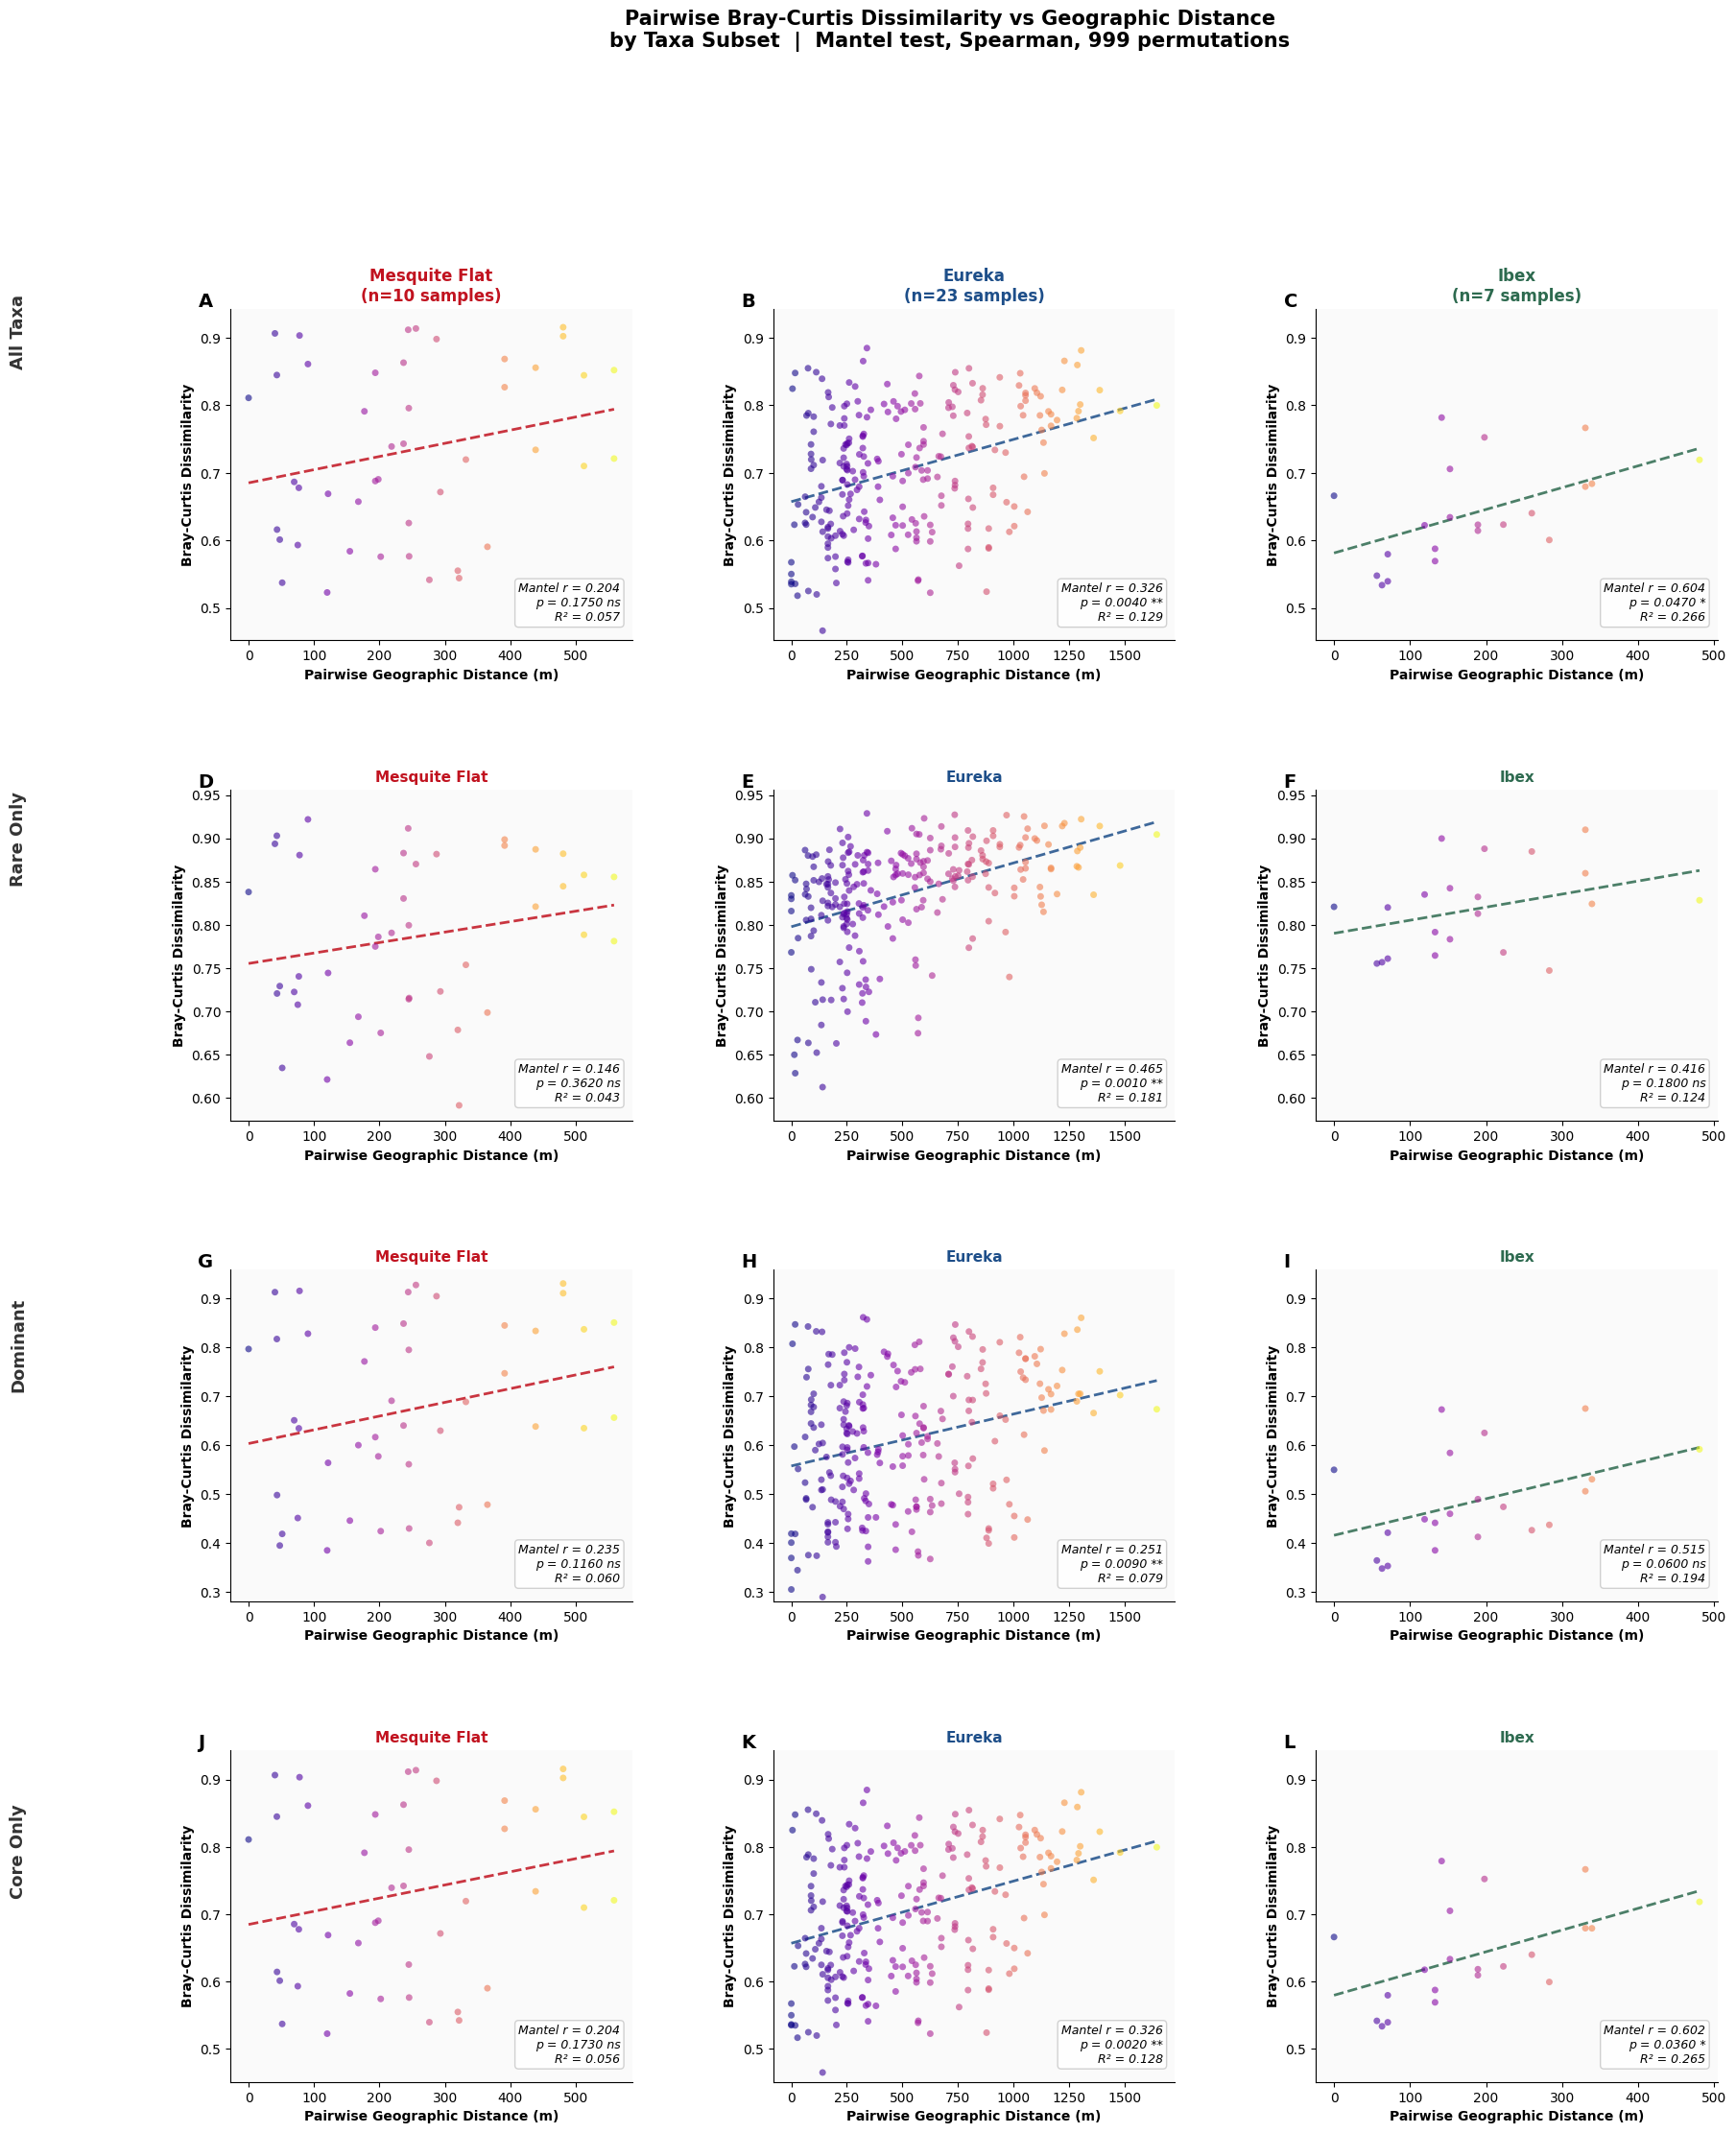

In [19]:
#CORE,DOMINANT,Rare Along transect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import mantel, DistanceMatrix
from scipy.stats import linregress

# ============================
# LOAD RELATIVE ABUNDANCE FILE
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

header_row = raw.iloc[1]
df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

# ============================
# FILTER PROKARYOTES
# ============================
micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")

# ============================
# BUILD SAMPLE x ZOTU MATRIX
# ============================
otu = (
    micro.set_index(zotu_col)[sample_cols]
    .T.fillna(0)
)
otu.index.name   = None
otu.columns.name = None

print(f"OTU matrix: {otu.shape[0]} samples x {otu.shape[1]} ZOTUs")

# ============================
# RARE / DOMINANT SPLIT
# rare = never exceeds 1% in any single sample
# ============================
zotu_max       = otu.max(axis=0)
rare_zotus     = zotu_max[zotu_max <= 1.0].index
dominant_zotus = zotu_max[zotu_max >  1.0].index

# ============================
# CORE PHYLA
# ≥80% prevalence in all three fields
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

eureka_samples   = [s for s in sample_cols
                    if get_field(s) == "Eureka"]
mesquite_samples = [s for s in sample_cols
                    if get_field(s) == "Mesquite"]
ibex_samples     = [s for s in sample_cols
                    if get_field(s) == "Ibex"]

phylum_grouped = micro.groupby("Phylum")[sample_cols].sum()

def get_prev(df, samps):
    return (df[samps] > 0).sum(axis=1) / len(samps)

core_phyla = get_prev(phylum_grouped, eureka_samples).loc[
    (get_prev(phylum_grouped, eureka_samples)   >= 0.80) &
    (get_prev(phylum_grouped, mesquite_samples) >= 0.80) &
    (get_prev(phylum_grouped, ibex_samples)     >= 0.80)
].index.tolist()

zotu_phylum = micro.set_index(zotu_col)["Phylum"].to_dict()
core_zotus  = [z for z in otu.columns
               if zotu_phylum.get(z) in core_phyla]

# ============================
# BUILD FOUR SUBSETS
# ============================
otu_all      = otu.copy()
otu_rare     = otu[rare_zotus].copy()
otu_dominant = otu[dominant_zotus].copy()
otu_core     = otu[core_zotus].copy()

print(f"\nSubset sizes:")
print(f"  All taxa:     {otu_all.shape[1]} ZOTUs")
print(f"  Rare only:    {otu_rare.shape[1]} ZOTUs")
print(f"  Dominant:     {otu_dominant.shape[1]} ZOTUs")
print(f"  Core only:    {otu_core.shape[1]} ZOTUs "
      f"({len(core_phyla)} phyla)")

# ============================
# TRANSECT DEFINITIONS
# ============================
transects = {
    "Mesquite Flat": [
        "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
        "MF.16A","MF.17A","MF.18B","MF.19A","MF.20A"
    ],
    "Eureka": [
        "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
        "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
        "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
        "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
    ],
    "Ibex": [
        "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
        "IX.6A","IX.7A"
    ]
}

field_colors = {
    "Mesquite Flat": "#c1121f",
    "Eureka":        "#1d4e89",
    "Ibex":          "#2d6a4f"
}

subsets = [
    ("All Taxa",     otu_all),
    ("Rare Only",    otu_rare),
    ("Dominant",     otu_dominant),
    ("Core Only",    otu_core),
]

# ============================
# MANTEL TEST FUNCTION
# ============================
def run_mantel(field, sample_list, otu_subset,
               coord_map, n_perm=999):

    samps = [s for s in sample_list
             if s in otu_subset.index and s in coord_map]
    n     = len(samps)

    if n < 4:
        return None

    # geographic distance matrix
    geo_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                lat1 = coord_map[samps[i]]["Lat"]
                lon1 = coord_map[samps[i]]["Lon"]
                lat2 = coord_map[samps[j]]["Lat"]
                lon2 = coord_map[samps[j]]["Lon"]
                geo_mat[i, j] = haversine_m(
                    lat1, lon1, lat2, lon2)

    # bray-curtis
    sub    = otu_subset.loc[samps].values.astype(float)
    bc_mat = squareform(pdist(sub, metric="braycurtis"))

    # mantel test
    ids    = list(range(n))
    dm_geo = DistanceMatrix(geo_mat, ids=ids)
    dm_bc  = DistanceMatrix(bc_mat,  ids=ids)

    r, p, _ = mantel(dm_geo, dm_bc,
                     method="spearman",
                     permutations=n_perm)

    sig = ("***" if p < 0.001 else
           "**"  if p < 0.01  else
           "*"   if p < 0.05  else "ns")

    idx   = np.triu_indices(n, k=1)
    x_geo = geo_mat[idx]
    y_bc  = bc_mat[idx]

    return {
        "r": r, "p": p, "sig": sig,
        "samps": samps, "n": n,
        "x_geo": x_geo, "y_bc": y_bc,
    }

# ============================
# RUN ALL COMBINATIONS
# ============================
print("\n" + "="*60)
print("PAIRWISE MANTEL — Bray-Curtis vs Geographic Distance")
print("Spearman correlation, 999 permutations")
print("="*60)

all_results = {}
for subset_name, otu_sub in subsets:
    print(f"\n--- {subset_name} ---")
    all_results[subset_name] = {}
    for field, slist in transects.items():
        res = run_mantel(field, slist, otu_sub,
                         coord_map, n_perm=999)
        all_results[subset_name][field] = res
        if res:
            print(f"  {field:<15} "
                  f"r={res['r']:.3f}  "
                  f"p={res['p']:.4f}  "
                  f"{res['sig']}")
        else:
            print(f"  {field:<15} insufficient samples")

# ============================
# FIGURE
# 4 rows (subsets) x 3 cols (fields)
# ============================
subset_names = [s for s, _ in subsets]
field_names  = list(transects.keys())

fig, axes = plt.subplots(
    4, 3, figsize=(20, 24),
    gridspec_kw={"hspace": 0.45, "wspace": 0.35})
fig.patch.set_facecolor("white")

panel_labels = "ABCDEFGHIJKL"
panel_idx    = 0

# compute shared y limits per row
y_lims = {}
for subset_name in subset_names:
    all_y = []
    for field in field_names:
        res = all_results[subset_name].get(field)
        if res:
            all_y.extend(res["y_bc"].tolist())
    if all_y:
        y_lims[subset_name] = (
            min(all_y) * 0.97,
            max(all_y) * 1.03
        )
    else:
        y_lims[subset_name] = (0, 1)

for ri, subset_name in enumerate(subset_names):
    for fi, field in enumerate(field_names):
        ax    = axes[ri, fi]
        color = field_colors[field]
        res   = all_results[subset_name].get(field)

        # panel label
        ax.text(-0.08, 1.05, panel_labels[panel_idx],
                transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="top")

        if res is None:
            ax.set_title(f"{field}\n(no data)",
                         fontsize=11, color=color)
            ax.set_visible(True)
            panel_idx += 1
            continue

        x = res["x_geo"]
        y = res["y_bc"]

        # scatter coloured by distance
        ax.scatter(x, y, c=x, cmap="plasma",
                   alpha=0.6, s=25, linewidths=0,
                   vmin=x.min(), vmax=x.max(),
                   zorder=3)

        # regression line + stats
        slope, intercept, r_val, p_val, _ = linregress(x, y)
        r2   = r_val ** 2
        x_ln = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_ln, slope * x_ln + intercept,
                color=color, linewidth=2,
                linestyle="--", alpha=0.85)

        ax.text(0.97, 0.05,
                f"Mantel r = {res['r']:.3f}\n"
                f"p = {res['p']:.4f} {res['sig']}\n"
                f"R² = {r2:.3f}",
                transform=ax.transAxes,
                ha="right", va="bottom",
                fontsize=9, style="italic",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white",
                          edgecolor="#cccccc",
                          alpha=0.9))

        # titles — only top row gets field name
        if ri == 0:
            ax.set_title(
                f"{field}\n(n={res['n']} samples)",
                fontsize=12, fontweight="bold",
                color=color)
        else:
            ax.set_title(
                f"{field}",
                fontsize=11, fontweight="bold",
                color=color)

        ax.set_xlabel("Pairwise Geographic Distance (m)",
                      fontsize=10, fontweight="bold")
        ax.set_ylabel("Bray-Curtis Dissimilarity",
                      fontsize=10, fontweight="bold")
        ax.set_ylim(y_lims[subset_name])
        ax.tick_params(labelsize=10)
        ax.set_facecolor("#fafafa")
        for sp in ["top", "right"]:
            ax.spines[sp].set_visible(False)

        panel_idx += 1

# ============================
# ROW LABELS — subset names
# ============================
row_y_positions = [0.87, 0.65, 0.43, 0.21]
for label, ypos in zip(subset_names, row_y_positions):
    fig.text(0.01, ypos, label,
             fontsize=13, fontweight="bold",
             va="center", rotation=90,
             color="#333333")

fig.suptitle(
    "Pairwise Bray-Curtis Dissimilarity vs Geographic Distance\n"
    "by Taxa Subset  |  Mantel test, Spearman, 999 permutations",
    fontsize=15, fontweight="bold", y=1.01)


plt.show()


In [ ]:
!pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 46.5 MB/s eta 0:00:00


In [20]:
pip install scikit-posthocs --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.0 MB/s eta 0:00:00


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal, spearmanr
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import mantel, DistanceMatrix
import scikit_posthocs as sp

# ============================
# LOAD RELATIVE ABUNDANCE FILE
# surface samples only
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

header_row = raw.iloc[1]
df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")
print(f"Total samples: {len(sample_cols)}")

# ============================
# FIELD + TRANSECT DEFINITIONS
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

eureka_samples   = [s for s in sample_cols
                    if get_field(s) == "Eureka"]
mesquite_samples = [s for s in sample_cols
                    if get_field(s) == "Mesquite"]
ibex_samples     = [s for s in sample_cols
                    if get_field(s) == "Ibex"]

# transect order for gradient analysis
mesquite_transect = [
    "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
    "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
]
eureka_transect = [
    "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
    "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
    "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
    "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
]
ibex_transect = [
    "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
    "IX.6A","IX.7A"
]

# filter to samples present in file
mesquite_t = [s for s in mesquite_transect
              if s in sample_cols]
eureka_t   = [s for s in eureka_transect
              if s in sample_cols]
ibex_t     = [s for s in ibex_transect
              if s in sample_cols]

print(f"\nEureka:   {len(eureka_samples)} samples "
      f"({len(eureka_t)} transect)")
print(f"Mesquite: {len(mesquite_samples)} samples "
      f"({len(mesquite_t)} transect)")
print(f"Ibex:     {len(ibex_samples)} samples "
      f"({len(ibex_t)} transect)")

# ============================
# BUILD OTU MATRIX
# ============================
otu = (
    micro.set_index(zotu_col)[sample_cols]
    .T.fillna(0)
)
otu.index.name   = None
otu.columns.name = None

# ============================
# IDENTIFY RARE ZOTUs
# max relative abundance ≤1%
# ============================
zotu_max   = otu.max(axis=0)
rare_zotus = zotu_max[zotu_max <= 1.0].index
otu_rare   = otu[rare_zotus].copy()

print(f"\nRare ZOTUs (≤1% max): {len(rare_zotus)}")

# ============================
# ALPHA DIVERSITY ON RARE TAXA
# ============================
def compute_alpha(counts):
    counts   = counts[counts > 0]
    if len(counts) == 0:
        return 0, 0, 0, 0
    N        = counts.sum()
    p        = counts / N
    shannon  = -np.sum(p * np.log(p))
    simpson  = 1 - np.sum(p ** 2)
    richness = len(counts)
    evenness = shannon / np.log(richness) if richness > 1 else 0
    return shannon, simpson, evenness, richness

records = []
for s in otu_rare.index:
    counts                           = otu_rare.loc[s].values.astype(float)
    shannon, simpson, evenness, rich = compute_alpha(counts)
    records.append({
        "Sample":   s,
        "Field":    get_field(s),
        "Shannon":  shannon,
        "Simpson":  simpson,
        "Evenness": evenness,
        "Richness": rich,
    })

alpha_rare = pd.DataFrame(records)

# ============================
# SECTION 1 — KRUSKAL-WALLIS
# rare taxa alpha by field
# ============================
print(f"\n{'='*60}")
print("SECTION 1 — RARE TAXA ALPHA DIVERSITY BY FIELD")
print(f"{'='*60}")

fields = ["Eureka", "Mesquite", "Ibex"]

def safe_kruskal(groups):
    valid = [g for g in groups if len(g) > 1]
    if len(valid) >= 2:
        return kruskal(*valid).pvalue
    return np.nan

for metric in ["Shannon", "Simpson", "Richness", "Evenness"]:
    groups = [alpha_rare[alpha_rare["Field"] == f][metric]
              for f in fields]
    p = safe_kruskal(groups)
    sig = ("***" if p < 0.001 else "**" if p < 0.01
           else "*" if p < 0.05 else "ns")
    print(f"  {metric:<12} p = {p:.4f}  {sig}")

    # field means
    for f in fields:
        vals = alpha_rare[alpha_rare["Field"] == f][metric]
        print(f"    {f:<12} mean={vals.mean():.3f}  "
              f"median={vals.median():.3f}  n={len(vals)}")

# ============================
# DUNN POST-HOC
# ============================
print(f"\nDunn test (BH correction):")
for metric in ["Shannon", "Simpson", "Richness"]:
    groups = [alpha_rare[alpha_rare["Field"] == f][metric]
              for f in fields]
    p_kw = safe_kruskal(groups)
    if p_kw < 0.05:
        data_list  = []
        group_list = []
        for vals, fname in zip(groups, fields):
            for v in vals:
                data_list.append(float(v))
                group_list.append(fname)
        combined = pd.DataFrame({"value": data_list,
                                  "group": group_list})
        result = sp.posthoc_dunn(
            combined, val_col="value",
            group_col="group", p_adjust="fdr_bh")
        print(f"\n  {metric}:")
        pairs = [("Eureka","Mesquite"),
                 ("Eureka","Ibex"),
                 ("Mesquite","Ibex")]
        for f1, f2 in pairs:
            p_adj = result.loc[f1, f2]
            sig   = ("***" if p_adj < 0.001 else
                     "**"  if p_adj < 0.01  else
                     "*"   if p_adj < 0.05  else "ns")
            print(f"    {f1} vs {f2}: p={p_adj:.4f} {sig}")

# ============================
# CHECK TEXT CLAIM
# "Mesquite Flat and Ibex supporting
# more diverse rare communities than Eureka"
# ============================
print(f"\nMean rare taxa Shannon by field:")
for f in fields:
    vals = alpha_rare[alpha_rare["Field"] == f]["Shannon"]
    print(f"  {f:<12} {vals.mean():.3f}")

# ============================
# SECTION 2 — TRANSECT GRADIENTS
# Spearman rho vs transect position
# ============================
print(f"\n{'='*60}")
print("SECTION 2 — RARE TAXA TRANSECT GRADIENTS")
print(f"{'='*60}")

transects = {
    "Eureka":   eureka_t,
    "Mesquite": mesquite_t,
    "Ibex":     ibex_t,
}

for field, slist in transects.items():
    samps = [s for s in slist if s in otu_rare.index]
    n     = len(samps)
    pos   = list(range(n))
    print(f"\n  {field} (n={n} transect samples):")

    for metric in ["Shannon", "Simpson",
                   "Evenness", "Richness"]:
        vals = [alpha_rare.loc[
                    alpha_rare["Sample"] == s,
                    metric].values[0]
                for s in samps]
        rho, p = spearmanr(pos, vals)
        sig    = ("***" if p < 0.001 else
                  "**"  if p < 0.01  else
                  "*"   if p < 0.05  else "ns")
        print(f"    {metric:<12} rho={rho:.3f}  "
              f"p={p:.4f}  {sig}")

# ============================
# SECTION 3 — MANTEL TEST
# rare taxa BC vs transect distance
# ============================
print(f"\n{'='*60}")
print("SECTION 3 — RARE TAXA BETA DIVERSITY MANTEL")
print(f"{'='*60}")

for field, slist in transects.items():
    samps = [s for s in slist if s in otu_rare.index]
    n     = len(samps)

    if n < 4:
        print(f"\n  {field}: insufficient samples (n={n})")
        continue

    # geographic distance
    geo_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j and samps[i] in coord_map \
                    and samps[j] in coord_map:
                lat1 = coord_map[samps[i]]["Lat"]
                lon1 = coord_map[samps[i]]["Lon"]
                lat2 = coord_map[samps[j]]["Lat"]
                lon2 = coord_map[samps[j]]["Lon"]
                geo_mat[i, j] = haversine_m(
                    lat1, lon1, lat2, lon2)

    # bray-curtis on rare taxa
    sub    = otu_rare.loc[samps].values.astype(float)
    bc_mat = squareform(pdist(sub, metric="braycurtis"))

    ids    = list(range(n))
    dm_geo = DistanceMatrix(geo_mat, ids=ids)
    dm_bc  = DistanceMatrix(bc_mat,  ids=ids)

    r, p, _ = mantel(dm_geo, dm_bc,
                     method="spearman",
                     permutations=999)
    sig = ("***" if p < 0.001 else
           "**"  if p < 0.01  else
           "*"   if p < 0.05  else "ns")

    print(f"\n  {field} (n={n} samples, "
          f"{n*(n-1)//2} pairs):")
    print(f"    Mantel r={r:.3f}  p={p:.4f}  {sig}")

# ============================
# VERIFY TEXT CLAIMS
# ============================
print(f"\n{'='*60}")
print("TEXT CLAIM VERIFICATION")
print(f"{'='*60}")

groups_sh   = [alpha_rare[alpha_rare["Field"]==f]["Shannon"]
               for f in fields]
groups_simp = [alpha_rare[alpha_rare["Field"]==f]["Simpson"]
               for f in fields]
groups_rich = [alpha_rare[alpha_rare["Field"]==f]["Richness"]
               for f in fields]
groups_even = [alpha_rare[alpha_rare["Field"]==f]["Evenness"]
               for f in fields]

p_sh   = safe_kruskal(groups_sh)
p_simp = safe_kruskal(groups_simp)
p_rich = safe_kruskal(groups_rich)
p_even = safe_kruskal(groups_even)

# Mesquite transect spearman
mf_samps = [s for s in mesquite_t
            if s in otu_rare.index]
mf_pos   = list(range(len(mf_samps)))

def get_metric_vals(samps, metric):
    return [alpha_rare.loc[
                alpha_rare["Sample"]==s,
                metric].values[0]
            for s in samps]

rho_mf_sh,   p_mf_sh   = spearmanr(
    mf_pos, get_metric_vals(mf_samps, "Shannon"))
rho_mf_even, p_mf_even = spearmanr(
    mf_pos, get_metric_vals(mf_samps, "Evenness"))
rho_mf_simp, p_mf_simp = spearmanr(
    mf_pos, get_metric_vals(mf_samps, "Simpson"))
rho_mf_rich, p_mf_rich = spearmanr(
    mf_pos, get_metric_vals(mf_samps, "Richness"))

claims = {
    "KW Shannon p=0.0006":
        abs(p_sh - 0.0006) < 0.001,
    "KW Simpson p=0.0006":
        abs(p_simp - 0.0006) < 0.001,
    "KW Richness p=0.0006":
        abs(p_rich - 0.0006) < 0.001,
    "KW Evenness p=0.8543":
        abs(p_even - 0.8543) < 0.01,
    "MF Shannon rho=0.62 p=0.030":
        abs(rho_mf_sh - 0.62) < 0.05 and
        abs(p_mf_sh - 0.030) < 0.01,
    "MF Evenness rho=0.67 p=0.012":
        abs(rho_mf_even - 0.67) < 0.05 and
        abs(p_mf_even - 0.012) < 0.01,
    "MF Simpson rho=0.56 p=0.046":
        abs(rho_mf_simp - 0.56) < 0.05 and
        abs(p_mf_simp - 0.046) < 0.01,
    "MF Richness rho=0.40 p=0.180 ns":
        abs(rho_mf_rich - 0.40) < 0.05 and
        abs(p_mf_rich - 0.180) < 0.02,
    "Rare ZOTUs n=5570":
        len(rare_zotus) == 5570,
}

all_pass = True
for claim, result in claims.items():
    status = "PASS" if result else "FAIL"
    if not result:
        all_pass = False
    print(f"  {status}  {claim}")

if all_pass:
    print("\nALL CHECKS PASS")
else:
    print("\nSOME CHECKS FAILED — see verified numbers above")

Prokaryotic ZOTUs: 6014
Total samples: 52

Eureka:   24 samples (23 transect)
Mesquite: 18 samples (11 transect)
Ibex:     10 samples (7 transect)

Rare ZOTUs (≤1% max): 5754

SECTION 1 — RARE TAXA ALPHA DIVERSITY BY FIELD
  Shannon      p = 0.0369  *
    Eureka       mean=5.569  median=5.590  n=24
    Mesquite     mean=6.034  median=6.042  n=18
    Ibex         mean=5.834  median=5.652  n=10
  Simpson      p = 0.1304  ns
    Eureka       mean=0.991  median=0.994  n=24
    Mesquite     mean=0.993  median=0.996  n=18
    Ibex         mean=0.994  median=0.994  n=10
  Richness     p = 0.2423  ns
    Eureka       mean=1317.875  median=1326.000  n=24
    Mesquite     mean=1520.278  median=1394.500  n=18
    Ibex         mean=1420.800  median=1320.000  n=10
  Evenness     p = 0.0184  *
    Eureka       mean=0.776  median=0.782  n=24
    Mesquite     mean=0.826  median=0.846  n=18
    Ibex         mean=0.804  median=0.787  n=10

Dunn test (BH correction):

  Shannon:
    Eureka vs Mesquite: p

Prokaryotic ZOTUs: 6014
Rare ZOTUs (≤1% max): 5754

MANTEL TEST — Rare Taxa BC vs Geographic Distance
Spearman correlation, 999 permutations

Eureka (n=23, 253 pairs): r=0.465  R²=0.216  p=0.0010  **
Mesquite (n=11, 55 pairs): r=0.172  R²=0.029  p=0.2710  ns
Ibex (n=7, 21 pairs): r=0.416  R²=0.173  p=0.1810  ns


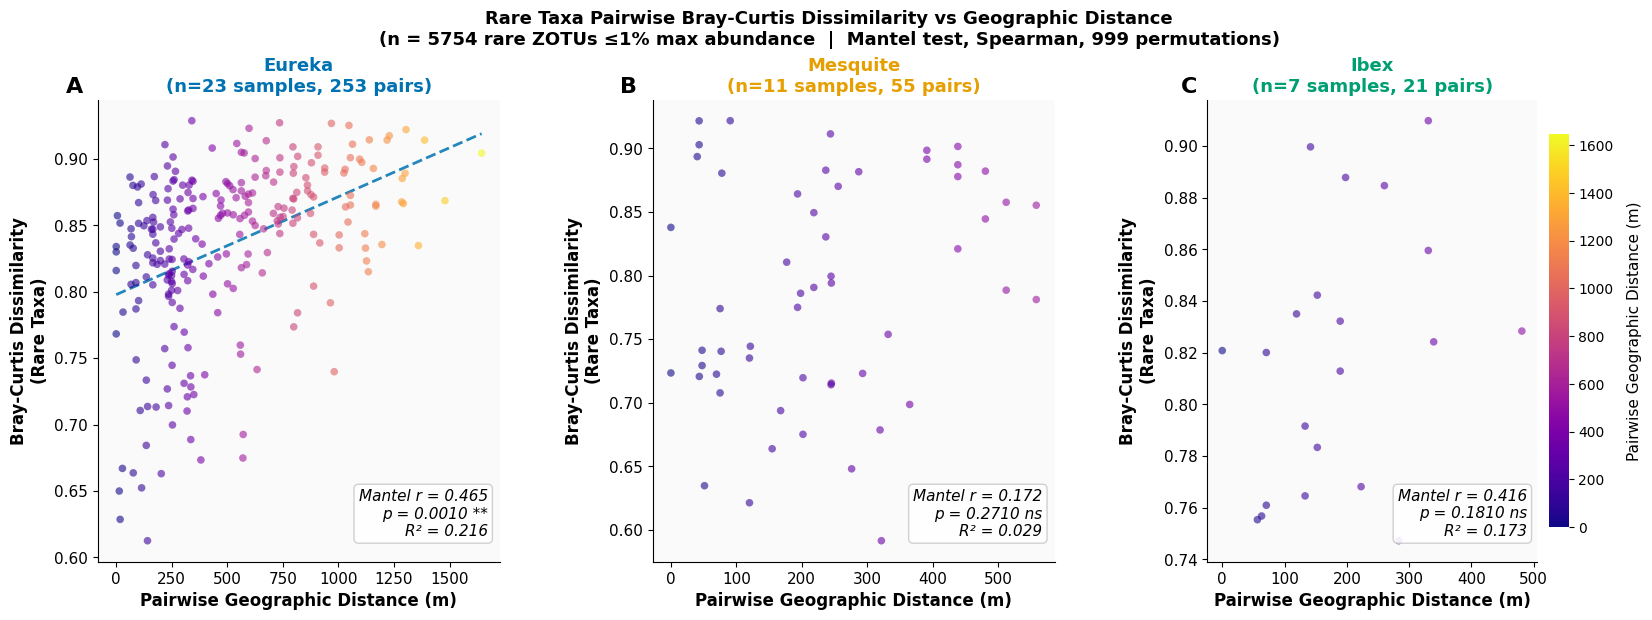

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import linregress
from skbio.stats.distance import mantel, DistanceMatrix

# ============================
# LOAD RELATIVE ABUNDANCE FILE
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

header_row = raw.iloc[1]
df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")

# ============================
# IDENTIFY RARE ZOTUs
# ============================
otu = (
    micro.set_index(zotu_col)[sample_cols]
    .T.fillna(0)
)
otu.index.name   = None
otu.columns.name = None

zotu_max   = otu.max(axis=0)
rare_zotus = zotu_max[zotu_max <= 1.0].index
otu_rare   = otu[rare_zotus].copy()

print(f"Rare ZOTUs (≤1% max): {len(rare_zotus)}")

# ============================
# TRANSECT DEFINITIONS
# ============================
transects = {
    "Eureka": [
        "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
        "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
        "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
        "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
    ],
    "Mesquite": [
        "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
        "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
    ],
    "Ibex": [
        "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
        "IX.6A","IX.7A"
    ]
}

field_colors = {
    "Eureka":   "#0072B2",
    "Mesquite": "#E69F00",
    "Ibex":     "#009E73",
}

# ============================
# RUN MANTEL PER FIELD
# ============================
def run_mantel_field(field, sample_list, otu_df,
                     coord_map, n_perm=999):
    samps = [s for s in sample_list
             if s in otu_df.index and s in coord_map]
    n     = len(samps)

    if n < 4:
        print(f"{field}: insufficient samples (n={n})")
        return None

    # geographic distance matrix
    geo_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                lat1 = coord_map[samps[i]]["Lat"]
                lon1 = coord_map[samps[i]]["Lon"]
                lat2 = coord_map[samps[j]]["Lat"]
                lon2 = coord_map[samps[j]]["Lon"]
                geo_mat[i, j] = haversine_m(
                    lat1, lon1, lat2, lon2)

    # bray-curtis on rare taxa
    sub    = otu_df.loc[samps].values.astype(float)
    bc_mat = squareform(pdist(sub, metric="braycurtis"))

    # mantel test
    ids    = list(range(n))
    dm_geo = DistanceMatrix(geo_mat, ids=ids)
    dm_bc  = DistanceMatrix(bc_mat,  ids=ids)

    r, p, _ = mantel(dm_geo, dm_bc,
                     method="spearman",
                     permutations=n_perm)
    r2  = r ** 2
    sig = ("***" if p < 0.001 else
           "**"  if p < 0.01  else
           "*"   if p < 0.05  else "ns")

    print(f"{field} (n={n}, {n*(n-1)//2} pairs): "
          f"r={r:.3f}  R²={r2:.3f}  p={p:.4f}  {sig}")

    idx   = np.triu_indices(n, k=1)
    x_geo = geo_mat[idx]
    y_bc  = bc_mat[idx]

    return {
        "r": r, "r2": r2, "p": p, "sig": sig,
        "n": n, "pairs": n*(n-1)//2,
        "x_geo": x_geo, "y_bc": y_bc,
        "significant": p < 0.05
    }

# ============================
# RUN ALL FIELDS
# ============================
print(f"\n{'='*55}")
print("MANTEL TEST — Rare Taxa BC vs Geographic Distance")
print("Spearman correlation, 999 permutations")
print(f"{'='*55}\n")

results = {}
for field, slist in transects.items():
    results[field] = run_mantel_field(
        field, slist, otu_rare, coord_map, n_perm=999)

# ============================
# FIGURE
# regression line only where p < 0.05
# ============================
fields  = [f for f in transects if results[f] is not None]

fig, axes = plt.subplots(
    1, len(fields),
    figsize=(6.5 * len(fields), 6),
    gridspec_kw={"wspace": 0.38})
fig.patch.set_facecolor("white")

if len(fields) == 1:
    axes = [axes]

# shared axis limits
all_x = np.concatenate([results[f]["x_geo"]
                         for f in fields])
all_y = np.concatenate([results[f]["y_bc"]
                         for f in fields])
vmin_global = all_x.min()
vmax_global = all_x.max()

panel_labels = "ABC"

for ax, field, panel_lbl in zip(axes, fields, panel_labels):
    res   = results[field]
    color = field_colors[field]

    x = res["x_geo"]
    y = res["y_bc"]

    # scatter coloured by distance
    ax.scatter(x, y, c=x, cmap="plasma",
               alpha=0.6, s=30, linewidths=0,
               vmin=vmin_global, vmax=vmax_global,
               zorder=3)

    # regression line ONLY if significant
    if res["significant"]:
        slope, intercept, _, _, _ = linregress(x, y)
        x_ln = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_ln, slope * x_ln + intercept,
                color=color, linewidth=2,
                linestyle="--", alpha=0.85)

    # stats box
    ax.text(0.97, 0.05,
            f"Mantel r = {res['r']:.3f}\n"
            f"p = {res['p']:.4f} {res['sig']}\n"
            f"R² = {res['r2']:.3f}",
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=11, style="italic",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="#cccccc",
                      alpha=0.9))

    ax.text(-0.08, 1.05, panel_lbl,
            transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top")

    ax.set_title(
        f"{field}\n(n={res['n']} samples, "
        f"{res['pairs']} pairs)",
        fontsize=13, fontweight="bold",
        color=color)
    ax.set_xlabel("Pairwise Geographic Distance (m)",
                  fontsize=12, fontweight="bold")
    ax.set_ylabel("Bray-Curtis Dissimilarity\n(Rare Taxa)",
                  fontsize=12, fontweight="bold")
    ax.tick_params(labelsize=11)
    ax.set_facecolor("#fafafa")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

# ============================
# SINGLE COLORBAR on rightmost panel
# ============================
sm = plt.cm.ScalarMappable(
         cmap="plasma",
         norm=plt.Normalize(vmin=vmin_global,
                            vmax=vmax_global))
sm.set_array([])
cb = fig.colorbar(sm, ax=axes[-1],
                  location="right",
                  shrink=0.85, pad=0.03, aspect=20)
cb.set_label("Pairwise Geographic Distance (m)",
             fontsize=11, labelpad=10)
cb.ax.tick_params(labelsize=10)
cb.outline.set_visible(False)

fig.suptitle(
    "Rare Taxa Pairwise Bray-Curtis Dissimilarity "
    "vs Geographic Distance\n"
    f"(n = {len(rare_zotus)} rare ZOTUs ≤1% max abundance  |  "
    "Mantel test, Spearman, 999 permutations)\n",
    fontsize=13, fontweight="bold", y=1.03)


plt.show()
